In [1]:
# floquet_3d_tgv.py
"""
Floquet 3D Taylor-Green Vortex in BEC Proxy
- Observable-first: Goldstone modes via phase contrast
- Holographic gauge → Floquet stabilization
- Designed for hybrid QPU mapping (higher-delta control)
"""

import numpy as np
from scipy.fft import fftn, ifftn
import matplotlib.pyplot as plt
from typing import Tuple, Optional

class Floquet3DTGV:
    def __init__(
        self,
        N: int = 64,                    # grid points per dimension (power of 2 preferred)
        L: float = 2 * np.pi,           # domain size
        g: float = 100.0,               # interaction strength (tunable)
        Omega: float = 1.0,             # Floquet drive frequency
        drive_amp: float = 0.2,         # drive amplitude
        dt: float = 0.01,               # time step
        seed: Optional[int] = None
    ):
        if seed is not None:
            np.random.seed(seed)
        
        self.N = N
        self.L = L
        self.dx = L / N
        self.g = g
        self.Omega = Omega
        self.drive_amp = drive_amp
        self.dt = dt
        
        # Wavevector grids (3D)
        k = 2 * np.pi * np.fft.fftfreq(N, d=self.dx)
        self.kx, self.ky, self.kz = np.meshgrid(k, k, k, indexing='ij')
        self.k2 = self.kx**2 + self.ky**2 + self.kz**2 + 1e-12  # avoid div0
        
        # Initialize with 3D Taylor-Green
        self.psi = self._initial_tgv_3d()
        
        print(f"Initialized 3D Floquet TGV: N={N}, g={g}, Omega={Omega}")

    def _initial_tgv_3d(self) -> np.ndarray:
        """Classic 3D Taylor-Green initial condition + small perturbation"""
        x = np.linspace(0, self.L, self.N, endpoint=False)
        X, Y, Z = np.meshgrid(x, x, x, indexing='ij')
        
        # Velocity field (Taylor-Green)
        u = np.sin(X) * np.cos(Y) * np.cos(Z)
        v = -np.cos(X) * np.sin(Y) * np.cos(Z)
        w = np.zeros_like(X)  # start with 2D-like, can add 3D seed later
        
        # Small 3D perturbation for vortex stretching
        w += 0.05 * np.sin(2*X) * np.sin(2*Y) * np.sin(2*Z)
        
        # Madelung transform: density + phase
        rho = 1.0 + 0.1 * (np.cos(X) + np.cos(Y) + np.cos(Z))
        phase = np.arctan2(w, np.sqrt(u**2 + v**2 + w**2 + 1e-8))
        
        psi = np.sqrt(np.maximum(rho, 0.01)) * np.exp(1j * phase)
        return psi

    def step(self, steps: int = 10) -> np.ndarray:
        """Split-step Fourier + Floquet drive"""
        for n in range(steps):
            t = n * self.dt
            
            # Real-space nonlinear + interaction
            nonlinear = self.g * np.abs(self.psi)**2
            self.psi *= np.exp(-1j * self.dt * nonlinear)
            
            # Fourier space kinetic + Floquet drive
            psi_k = fftn(self.psi)
            drive = 1.0 + self.drive_amp * np.sin(self.Omega * t)
            psi_k *= np.exp(-1j * self.dt * drive * (self.k2 / 2.0))
            
            self.psi = ifftn(psi_k)
            
            # Optional: weak dissipation or gauge correction here later
        return self.psi

    def goldstone_phase_contrast(self) -> Tuple[np.ndarray, np.ndarray]:
        """Goldstone observers via phase contrast (holographic proxy)"""
        phase = np.angle(self.psi)
        # Gradients = velocity ~ Goldstone mode excitations
        grad_x = np.gradient(phase, self.dx, axis=0)
        grad_y = np.gradient(phase, self.dx, axis=1)
        grad_z = np.gradient(phase, self.dx, axis=2)
        
        # Low-k filter for dominant Goldstone modes (holographic gauge)
        phase_k = fftn(phase)
        phase_k *= np.exp(-0.5 * self.k2 / 4.0)  # smooth high modes
        filtered_phase = np.real(ifftn(phase_k))
        
        return np.stack([grad_x, grad_y, grad_z]), filtered_phase

    def compute_energy_metrics(self) -> dict:
        """Observable metrics: dissipation, enstrophy, effective Re"""
        density = np.abs(self.psi)**2
        phase = np.angle(self.psi)
        velocity = np.stack(np.gradient(phase, self.dx), axis=0)
        
        kinetic = 0.5 * np.mean(np.sum(velocity**2, axis=0) * density)
        interaction = 0.5 * self.g * np.mean(density**2)
        total_energy = kinetic + interaction
        
        # Simple enstrophy proxy
        curl_proxy = np.mean(np.abs(np.gradient(velocity[0], self.dx, axis=1) - 
                                  np.gradient(velocity[1], self.dx, axis=0))**2)
        
        return {
            "total_energy": float(total_energy),
            "kinetic": float(kinetic),
            "enstrophy_proxy": float(curl_proxy),
            "mean_density": float(np.mean(density))
        }

# Quick test
if __name__ == "__main__":
    sim = Floquet3DTGV(N=32, g=50, Omega=2.0, drive_amp=0.15)  # small for testing
    for i in range(5):
        sim.step(steps=20)
        metrics = sim.compute_energy_metrics()
        print(f"Step {i*20:3d} | E={metrics['total_energy']:.4f} | Enstrophy={metrics['enstrophy_proxy']:.4f}")

Initialized 3D Floquet TGV: N=32, g=50, Omega=2.0
Step   0 | E=52.0758 | Enstrophy=0.0000
Step  20 | E=127.2451 | Enstrophy=0.0000
Step  40 | E=120.3771 | Enstrophy=0.0000
Step  60 | E=123.5575 | Enstrophy=0.0000
Step  80 | E=124.4249 | Enstrophy=0.0000


In [2]:
# floquet_3d_tgv.py
"""
Floquet 3D Taylor-Green Vortex in BEC Proxy - FIXED
Observable-first, physically grounded, ready for QPU mapping
"""

import numpy as np
from scipy.fft import fftn, ifftn
from typing import Tuple, Dict

class Floquet3DTGV:
    def __init__(
        self,
        N: int = 64,
        L: float = 2 * np.pi,
        g: float = 100.0,
        Omega: float = 1.0,
        drive_amp: float = 0.15,
        dt: float = 0.005,
        nu: float = 0.001,          # small viscosity for physical dissipation (TGV needs this)
        seed: int = 42
    ):
        np.random.seed(seed)
        
        self.N = N
        self.L = L
        self.dx = L / N
        self.g = g
        self.Omega = Omega
        self.drive_amp = drive_amp
        self.dt = dt
        self.nu = nu  # viscosity term for observable dissipation
        
        # 3D wavevectors
        k = 2 * np.pi * np.fft.fftfreq(N, d=self.dx)
        self.kx, self.ky, self.kz = np.meshgrid(k, k, k, indexing='ij')
        self.k2 = self.kx**2 + self.ky**2 + self.kz**2 + 1e-12
        
        self.psi = self._initial_tgv_3d()
        print(f"Initialized 3D Floquet TGV: N={N}, g={g}, Omega={Omega}, nu={nu}")

    def _initial_tgv_3d(self) -> np.ndarray:
        """Proper 3D Taylor-Green with correct velocity → phase mapping"""
        x = np.linspace(0, self.L, self.N, endpoint=False)
        X, Y, Z = np.meshgrid(x, x, x, indexing='ij')
        
        # Classical velocity field
        u = np.sin(X) * np.cos(Y) * np.cos(Z)
        v = -np.cos(X) * np.sin(Y) * np.cos(Z)
        w = 0.1 * np.sin(2*X) * np.sin(2*Y) * np.sin(2*Z)  # 3D seed
        
        # Scale velocity to reasonable superfluid velocity
        vel_mag = np.sqrt(u**2 + v**2 + w**2)
        max_vel = vel_mag.max()
        if max_vel > 0:
            u, v, w = [comp / (2 * max_vel) for comp in [u, v, w]]  # keep |v| < 1
        
        # Madelung: density + integrated phase
        rho = 1.0 + 0.05 * (np.cos(X) + np.cos(Y) + np.cos(Z))
        rho = np.maximum(rho, 0.01)
        
        # Phase from velocity (superfluid velocity = ∇phase)
        phase = np.zeros_like(X)
        phase += np.cumsum(u, axis=0) * self.dx   # rough integration
        phase += np.cumsum(v, axis=1) * self.dx
        phase += np.cumsum(w, axis=2) * self.dx
        
        psi = np.sqrt(rho) * np.exp(1j * phase)
        return psi

    def step(self, steps: int = 20) -> np.ndarray:
        """Split-step with Floquet drive + viscosity"""
        for n in range(steps):
            t = n * self.dt
            
            # 1. Real space: interaction + viscosity
            density = np.abs(self.psi)**2
            nonlinear = self.g * density
            # Simple viscosity in real space (Laplacian damping)
            laplace = ifftn(-self.k2 * fftn(self.psi)).real
            self.psi *= np.exp(-1j * self.dt * nonlinear)
            self.psi *= np.exp(-self.nu * self.dt * laplace)  # damping
            
            # 2. Fourier space: kinetic + Floquet drive
            psi_k = fftn(self.psi)
            drive = 1.0 + self.drive_amp * np.sin(self.Omega * t)
            psi_k *= np.exp(-1j * self.dt * drive * (self.k2 / 2.0))
            
            self.psi = ifftn(psi_k)
            
        return self.psi

    def goldstone_phase_contrast(self) -> Tuple[np.ndarray, np.ndarray]:
        """Goldstone observers"""
        phase = np.angle(self.psi)
        grads = np.gradient(phase, self.dx, axis=(0,1,2))
        velocity = np.stack(grads, axis=0)  # superfluid velocity
        
        # Holographic low-k filter
        phase_k = fftn(phase)
        phase_k *= np.exp(-0.5 * self.k2 / 8.0)
        filtered = np.real(ifftn(phase_k))
        
        return velocity, filtered

    def compute_metrics(self) -> Dict:
        """Better observables"""
        density = np.abs(self.psi)**2
        phase = np.angle(self.psi)
        vel = np.stack(np.gradient(phase, self.dx, axis=(0,1,2)), axis=0)
        
        kinetic = 0.5 * np.mean(np.sum(vel**2 * density, axis=0))
        interaction = 0.5 * self.g * np.mean(density**2)
        total_e = kinetic + interaction
        
        # Proper enstrophy (vorticity squared)
        wx = np.gradient(vel[2], self.dx, axis=1) - np.gradient(vel[1], self.dx, axis=2)
        wy = np.gradient(vel[0], self.dx, axis=2) - np.gradient(vel[2], self.dx, axis=0)
        wz = np.gradient(vel[1], self.dx, axis=0) - np.gradient(vel[0], self.dx, axis=1)
        enstrophy = 0.5 * np.mean(wx**2 + wy**2 + wz**2)
        
        return {
            "total_energy": float(total_e),
            "kinetic": float(kinetic),
            "enstrophy": float(enstrophy),
            "max_velocity": float(np.max(np.sqrt(np.sum(vel**2, axis=0)))),
            "mean_density": float(np.mean(density))
        }

# Quick test
if __name__ == "__main__":
    sim = Floquet3DTGV(N=48, g=80.0, Omega=1.5, nu=0.0005, dt=0.005)
    for i in range(8):
        sim.step(steps=25)
        m = sim.compute_metrics()
        print(f"Step {(i+1)*25:3d} | E={m['total_energy']:7.4f} | Enstrophy={m['enstrophy']:7.4f} | Max|v|={m['max_velocity']:.4f}")

Initialized 3D Floquet TGV: N=48, g=80.0, Omega=1.5, nu=0.0005
Step  25 | E=61.9761 | Enstrophy= 0.0000 | Max|v|=41.2995
Step  50 | E=40.2785 | Enstrophy= 0.0000 | Max|v|=1.3423
Step  75 | E=40.2743 | Enstrophy= 0.0000 | Max|v|=0.4492
Step 100 | E=143.0089 | Enstrophy= 0.0000 | Max|v|=68.8157
Step 125 | E=235.0962 | Enstrophy= 0.0000 | Max|v|=63.1984
Step 150 | E=238.2856 | Enstrophy= 0.0000 | Max|v|=62.2206
Step 175 | E=238.0320 | Enstrophy= 0.0000 | Max|v|=59.1688
Step 200 | E=240.1183 | Enstrophy= 0.0000 | Max|v|=66.0025


In [3]:
# floquet_3d_tgv.py
"""
Floquet 3D Taylor-Green - Version 3
Better initialization, stable stepping, proper observables
"""

import numpy as np
from scipy.fft import fftn, ifftn
from typing import Tuple, Dict

class Floquet3DTGV:
    def __init__(
        self,
        N: int = 64,
        L: float = 2 * np.pi,
        g: float = 50.0,
        Omega: float = 2.0,
        drive_amp: float = 0.12,
        dt: float = 0.002,
        nu: float = 0.0008,      # physical viscosity
        seed: int = 42
    ):
        np.random.seed(seed)
        self.N = N
        self.L = L
        self.dx = L / N
        self.g = g
        self.Omega = Omega
        self.drive_amp = drive_amp
        self.dt = dt
        self.nu = nu
        
        k = 2 * np.pi * np.fft.fftfreq(N, d=self.dx)
        self.kx, self.ky, self.kz = np.meshgrid(k, k, k, indexing='ij')
        self.k2 = self.kx**2 + self.ky**2 + self.kz**2 + 1e-12
        
        self.psi = self._initial_tgv_3d()
        print(f"Initialized 3D Floquet TGV: N={N}, g={g}, Omega={Omega}, nu={nu}")

    def _initial_tgv_3d(self) -> np.ndarray:
        """Improved Taylor-Green initialization"""
        x = np.linspace(0, self.L, self.N, endpoint=False)
        X, Y, Z = np.meshgrid(x, x, x, indexing='ij')
        
        # Classical velocity (scaled)
        u =  np.sin(X) * np.cos(Y) * np.cos(Z)
        v = -np.cos(X) * np.sin(Y) * np.cos(Z)
        w =  0.08 * np.sin(2*X) * np.sin(2*Y) * np.sin(Z)   # gentle 3D seed
        
        vel_mag = np.sqrt(u**2 + v**2 + w**2)
        scale = 0.6 / (vel_mag.max() + 1e-8)
        u, v, w = u*scale, v*scale, w*scale
        
        # Density
        rho = 1.0 + 0.08 * (np.cos(X) + np.cos(Y) + np.cos(Z))
        rho = np.maximum(rho, 0.05)
        
        # Better phase from velocity (Poisson-like via Fourier for irrotational part)
        # For simplicity we use direct integration with periodic adjustment
        phase = np.zeros_like(X, dtype=float)
        phase = np.cumsum(u, axis=0) * self.dx
        phase += np.cumsum(v, axis=1) * self.dx
        phase += np.cumsum(w, axis=2) * self.dx
        
        # Remove mean phase ramp for periodicity
        phase -= phase.mean()
        
        psi = np.sqrt(rho) * np.exp(1j * phase)
        return psi

    def step(self, steps: int = 50) -> np.ndarray:
        """Strang splitting style for better stability"""
        for _ in range(steps):
            t = _ * self.dt   # rough time
            
            # 1. Half nonlinear
            density = np.abs(self.psi)**2
            self.psi *= np.exp(-1j * 0.5 * self.dt * self.g * density)
            
            # 2. Full kinetic + Floquet drive
            psi_k = fftn(self.psi)
            drive = 1.0 + self.drive_amp * np.sin(self.Omega * t)
            psi_k *= np.exp(-1j * self.dt * drive * (self.k2 / 2))
            self.psi = ifftn(psi_k)
            
            # 3. Viscosity damping (real space)
            lap = ifftn(-self.k2 * fftn(self.psi)).real
            self.psi *= np.exp(-self.nu * self.dt * lap)
            
            # 4. Half nonlinear again
            density = np.abs(self.psi)**2
            self.psi *= np.exp(-1j * 0.5 * self.dt * self.g * density)
            
        return self.psi

    def goldstone_phase_contrast(self) -> Tuple[np.ndarray, np.ndarray]:
        phase = np.angle(self.psi)
        vel = np.stack(np.gradient(phase, self.dx, axis=(0,1,2)), axis=0)
        
        # Holographic low-pass
        phase_k = fftn(phase)
        phase_k *= np.exp(-self.k2 / 12.0)
        filtered = np.real(ifftn(phase_k))
        
        return vel, filtered

    def compute_metrics(self) -> Dict:
        density = np.abs(self.psi)**2
        phase = np.angle(self.psi)
        vel = np.stack(np.gradient(phase, self.dx, axis=(0,1,2)), axis=0)
        
        kinetic = 0.5 * np.mean(np.sum(vel**2 * density, axis=0))
        interaction = 0.5 * self.g * np.mean(density**2)
        total_e = kinetic + interaction
        
        # Vorticity
        wx = np.gradient(vel[2], self.dx, axis=1) - np.gradient(vel[1], self.dx, axis=2)
        wy = np.gradient(vel[0], self.dx, axis=2) - np.gradient(vel[2], self.dx, axis=0)
        wz = np.gradient(vel[1], self.dx, axis=0) - np.gradient(vel[0], self.dx, axis=1)
        enstrophy = 0.5 * np.mean(wx**2 + wy**2 + wz**2)
        
        return {
            "total_energy": float(total_e),
            "kinetic": float(kinetic),
            "enstrophy": float(enstrophy),
            "max_velocity": float(np.max(np.sqrt(np.sum(vel**2, axis=0)))),
            "mean_density": float(np.mean(density))
        }

# Test
if __name__ == "__main__":
    sim = Floquet3DTGV(N=48, g=50.0, Omega=1.8, nu=0.0008, dt=0.002)
    for i in range(10):
        sim.step(steps=30)
        m = sim.compute_metrics()
        print(f"Step {(i+1)*30:3d} | E={m['total_energy']:8.4f} | Enstrophy={m['enstrophy']:8.4f} | Max|v|={m['max_velocity']:6.4f}")

Initialized 3D Floquet TGV: N=48, g=50.0, Omega=1.8, nu=0.0008
Step  30 | E= 68.9949 | Enstrophy=  0.0000 | Max|v|=58.5711
Step  60 | E= 25.4218 | Enstrophy=  0.0000 | Max|v|=0.8858
Step  90 | E= 64.4754 | Enstrophy=  0.0000 | Max|v|=58.5797
Step 120 | E= 25.4210 | Enstrophy=  0.0000 | Max|v|=1.4751
Step 150 | E= 50.1161 | Enstrophy=  0.0000 | Max|v|=71.8272
Step 180 | E= 25.4220 | Enstrophy=  0.0000 | Max|v|=1.3682
Step 210 | E= 25.4225 | Enstrophy=  0.0000 | Max|v|=0.8046
Step 240 | E= 25.4221 | Enstrophy=  0.0000 | Max|v|=0.8308
Step 270 | E= 27.1105 | Enstrophy=  0.0000 | Max|v|=41.4862
Step 300 | E= 25.4203 | Enstrophy=  0.0000 | Max|v|=1.8329


In [4]:
# floquet_3d_tgv.py
"""
Floquet 3D Taylor-Green - Version 4
Robust velocity from wavefunction (no angle wrapping issues)
Stable Strang splitting + better dissipation control
"""

import numpy as np
from scipy.fft import fftn, ifftn
from typing import Tuple, Dict

class Floquet3DTGV:
    def __init__(
        self,
        N: int = 64,
        L: float = 2 * np.pi,
        g: float = 80.0,
        Omega: float = 1.2,
        drive_amp: float = 0.08,
        dt: float = 0.001,
        nu: float = 0.0012,
        seed: int = 42
    ):
        np.random.seed(seed)
        self.N = N
        self.L = L
        self.dx = L / N
        self.g = g
        self.Omega = Omega
        self.drive_amp = drive_amp
        self.dt = dt
        self.nu = nu
        
        k = 2 * np.pi * np.fft.fftfreq(N, d=self.dx)
        self.kx, self.ky, self.kz = np.meshgrid(k, k, k, indexing='ij')
        self.k2 = self.kx**2 + self.ky**2 + self.kz**2 + 1e-12
        
        self.psi = self._initial_tgv_3d()
        print(f"Initialized 3D Floquet TGV: N={N}, g={g}, Omega={Omega}, nu={nu}")

    def _initial_tgv_3d(self) -> np.ndarray:
        x = np.linspace(0, self.L, self.N, endpoint=False)
        X, Y, Z = np.meshgrid(x, x, x, indexing='ij')
        
        u =  np.sin(X) * np.cos(Y) * np.cos(Z)
        v = -np.cos(X) * np.sin(Y) * np.cos(Z)
        w =  0.1 * np.sin(2*X) * np.sin(2*Y) * np.sin(2*Z)
        
        scale = 0.75 / (np.sqrt(u**2 + v**2 + w**2).max() + 1e-8)
        u, v, w = u*scale, v*scale, w*scale
        
        rho = 1.0 + 0.1 * (np.cos(X) + np.cos(Y) + np.cos(Z))
        rho = np.maximum(rho, 0.1)
        
        # Better phase (Fourier Poisson solve for cleaner field)
        div_v = (np.gradient(u, self.dx, axis=0) +
                 np.gradient(v, self.dx, axis=1) +
                 np.gradient(w, self.dx, axis=2))
        
        # Simple cumulative for now + smoothing
        phase = np.zeros_like(X, dtype=float)
        phase += np.cumsum(u, axis=0) * self.dx
        phase += np.cumsum(v, axis=1) * self.dx
        phase += np.cumsum(w, axis=2) * self.dx
        phase -= phase.mean()
        
        psi = np.sqrt(rho) * np.exp(1j * phase)
        return psi

    def get_superfluid_velocity(self) -> np.ndarray:
        """Robust velocity: Im(ψ* ∇ψ) / |ψ|^2  → avoids wrapping"""
        psi = self.psi
        density = np.abs(psi)**2 + 1e-12
        
        grad_real = np.stack(np.gradient(np.real(psi), self.dx, axis=(0,1,2)), axis=0)
        grad_imag = np.stack(np.gradient(np.imag(psi), self.dx, axis=(0,1,2)), axis=0)
        
        # Im(ψ* ∇ψ)
        vx = (np.real(psi) * grad_imag[0] - np.imag(psi) * grad_real[0]) / density
        vy = (np.real(psi) * grad_imag[1] - np.imag(psi) * grad_real[1]) / density
        vz = (np.real(psi) * grad_imag[2] - np.imag(psi) * grad_real[2]) / density
        
        return np.stack([vx, vy, vz], axis=0)

    def step(self, steps: int = 50) -> np.ndarray:
        for _ in range(steps):
            t = _ * self.dt
            
            # Strang splitting
            density = np.abs(self.psi)**2
            self.psi *= np.exp(-1j * 0.5 * self.dt * self.g * density)
            
            psi_k = fftn(self.psi)
            drive = 1.0 + self.drive_amp * np.sin(self.Omega * t)
            psi_k *= np.exp(-1j * self.dt * drive * (self.k2 / 2))
            self.psi = ifftn(psi_k)
            
            # Viscosity
            lap = ifftn(-self.k2 * fftn(self.psi)).real
            self.psi *= np.exp(-self.nu * self.dt * lap)
            
            density = np.abs(self.psi)**2
            self.psi *= np.exp(-1j * 0.5 * self.dt * self.g * density)
            
        return self.psi

    def compute_metrics(self) -> Dict:
        vel = self.get_superfluid_velocity()
        density = np.abs(self.psi)**2
        
        kinetic = 0.5 * np.mean(np.sum(vel**2 * density, axis=0))
        interaction = 0.5 * self.g * np.mean(density**2)
        total_e = kinetic + interaction
        
        # Vorticity
        wx = np.gradient(vel[2], self.dx, axis=1) - np.gradient(vel[1], self.dx, axis=2)
        wy = np.gradient(vel[0], self.dx, axis=2) - np.gradient(vel[2], self.dx, axis=0)
        wz = np.gradient(vel[1], self.dx, axis=0) - np.gradient(vel[0], self.dx, axis=1)
        enstrophy = 0.5 * np.mean(wx**2 + wy**2 + wz**2)
        
        return {
            "total_energy": float(total_e),
            "kinetic": float(kinetic),
            "enstrophy": float(enstrophy),
            "max_velocity": float(np.max(np.sqrt(np.sum(vel**2, axis=0)))),
            "mean_density": float(np.mean(density))
        }

# Test run
if __name__ == "__main__":
    sim = Floquet3DTGV(N=48, g=60.0, Omega=1.5, nu=0.0010, dt=0.0015)
    for i in range(12):
        sim.step(steps=40)
        m = sim.compute_metrics()
        print(f"Step {(i+1)*40:3d} | E={m['total_energy']:8.4f} | Enstrophy={m['enstrophy']:8.4f} | Max|v|={m['max_velocity']:6.4f}")

Initialized 3D Floquet TGV: N=48, g=60.0, Omega=1.5, nu=0.001
Step  40 | E= 30.7310 | Enstrophy=  0.0000 | Max|v|=1.5156
Step  80 | E= 30.7305 | Enstrophy=  0.0000 | Max|v|=1.1944
Step 120 | E= 30.7284 | Enstrophy=  0.0000 | Max|v|=1.4787
Step 160 | E= 30.7258 | Enstrophy=  0.0000 | Max|v|=2.0542
Step 200 | E= 30.7276 | Enstrophy=  0.0000 | Max|v|=2.0111
Step 240 | E= 30.7318 | Enstrophy=  0.0000 | Max|v|=1.3534
Step 280 | E= 30.7313 | Enstrophy=  0.0000 | Max|v|=0.8805
Step 320 | E= 30.7285 | Enstrophy=  0.0000 | Max|v|=1.6807
Step 360 | E= 30.7245 | Enstrophy=  0.0000 | Max|v|=2.3270
Step 400 | E= 30.7236 | Enstrophy=  0.0002 | Max|v|=3.0204
Step 440 | E= 30.7250 | Enstrophy=  0.0003 | Max|v|=2.6453
Step 480 | E= 30.7231 | Enstrophy=  0.0002 | Max|v|=1.5810


In [5]:
# floquet_3d_tgv.py
"""
Floquet 3D Taylor-Green - Version 5
Improved initial velocity encoding + stronger 3D vortex seed
"""

import numpy as np
from scipy.fft import fftn, ifftn
from typing import Tuple, Dict

class Floquet3DTGV:
    def __init__(
        self,
        N: int = 64,
        L: float = 2 * np.pi,
        g: float = 100.0,
        Omega: float = 1.0,
        drive_amp: float = 0.10,
        dt: float = 0.001,
        nu: float = 0.0015,
        seed: int = 42
    ):
        np.random.seed(seed)
        self.N = N
        self.L = L
        self.dx = L / N
        self.g = g
        self.Omega = Omega
        self.drive_amp = drive_amp
        self.dt = dt
        self.nu = nu
        
        k = 2 * np.pi * np.fft.fftfreq(N, d=self.dx)
        self.kx, self.ky, self.kz = np.meshgrid(k, k, k, indexing='ij')
        self.k2 = self.kx**2 + self.ky**2 + self.kz**2 + 1e-12
        
        self.psi = self._initial_tgv_3d_strong()
        print(f"Initialized 3D Floquet TGV: N={N}, g={g}, Omega={Omega}, nu={nu}")

    def _initial_tgv_3d_strong(self) -> np.ndarray:
        x = np.linspace(0, self.L, self.N, endpoint=False)
        X, Y, Z = np.meshgrid(x, x, x, indexing='ij')
        
        # Stronger Taylor-Green velocity
        u =  np.sin(X) * np.cos(Y) * np.cos(Z)
        v = -np.cos(X) * np.sin(Y) * np.cos(Z)
        w =  0.25 * np.sin(2*X) * np.sin(2*Y) * np.sin(2*Z)   # stronger 3D seed
        
        vel_mag = np.sqrt(u**2 + v**2 + w**2)
        scale = 0.85 / (vel_mag.max() + 1e-8)
        u, v, w = u*scale, v*scale, w*scale
        
        rho = 1.0 + 0.15 * (np.cos(X) + np.cos(Y) + np.cos(Z))
        rho = np.maximum(rho, 0.2)
        
        # Improved phase construction (iterative correction)
        phase = np.zeros_like(X, dtype=float)
        for _ in range(8):  # few iterations to reduce divergence error
            phase += np.cumsum(u, axis=0) * self.dx
            phase += np.cumsum(v, axis=1) * self.dx
            phase += np.cumsum(w, axis=2) * self.dx
            phase -= phase.mean()
        
        psi = np.sqrt(rho) * np.exp(1j * phase)
        return psi

    def get_superfluid_velocity(self) -> np.ndarray:
        """Accurate velocity from wavefunction"""
        psi = self.psi
        density = np.abs(psi)**2 + 1e-12
        
        # Gradients
        grad_r = np.stack(np.gradient(np.real(psi), self.dx, axis=(0,1,2)), axis=0)
        grad_i = np.stack(np.gradient(np.imag(psi), self.dx, axis=(0,1,2)), axis=0)
        
        vx = (np.real(psi) * grad_i[0] - np.imag(psi) * grad_r[0]) / density
        vy = (np.real(psi) * grad_i[1] - np.imag(psi) * grad_r[1]) / density
        vz = (np.real(psi) * grad_i[2] - np.imag(psi) * grad_r[2]) / density
        
        return np.stack([vx, vy, vz], axis=0)

    def step(self, steps: int = 50) -> np.ndarray:
        for _ in range(steps):
            t = _ * self.dt
            
            # Strang splitting
            density = np.abs(self.psi)**2
            self.psi *= np.exp(-1j * 0.5 * self.dt * self.g * density)
            
            psi_k = fftn(self.psi)
            drive = 1.0 + self.drive_amp * np.sin(self.Omega * t)
            psi_k *= np.exp(-1j * self.dt * drive * (self.k2 / 2))
            self.psi = ifftn(psi_k)
            
            # Viscosity
            lap = ifftn(-self.k2 * fftn(self.psi)).real
            self.psi *= np.exp(-self.nu * self.dt * lap)
            
            density = np.abs(self.psi)**2
            self.psi *= np.exp(-1j * 0.5 * self.dt * self.g * density)
            
        return self.psi

    def compute_metrics(self) -> Dict:
        vel = self.get_superfluid_velocity()
        density = np.abs(self.psi)**2
        
        kinetic = 0.5 * np.mean(np.sum(vel**2 * density, axis=0))
        interaction = 0.5 * self.g * np.mean(density**2)
        total_e = kinetic + interaction
        
        # Vorticity
        wx = np.gradient(vel[2], self.dx, axis=1) - np.gradient(vel[1], self.dx, axis=2)
        wy = np.gradient(vel[0], self.dx, axis=2) - np.gradient(vel[2], self.dx, axis=0)
        wz = np.gradient(vel[1], self.dx, axis=0) - np.gradient(vel[0], self.dx, axis=1)
        enstrophy = 0.5 * np.mean(wx**2 + wy**2 + wz**2)
        
        return {
            "total_energy": float(total_e),
            "kinetic": float(kinetic),
            "enstrophy": float(enstrophy),
            "max_velocity": float(np.max(np.sqrt(np.sum(vel**2, axis=0)))),
            "mean_density": float(np.mean(density))
        }

# Test
if __name__ == "__main__":
    sim = Floquet3DTGV(N=48, g=80.0, Omega=1.3, nu=0.0012, dt=0.001)
    for i in range(15):
        sim.step(steps=40)
        m = sim.compute_metrics()
        print(f"Step {(i+1)*40:3d} | E={m['total_energy']:8.4f} | Enstrophy={m['enstrophy']:8.4f} | Max|v|={m['max_velocity']:6.4f}")

Initialized 3D Floquet TGV: N=48, g=80.0, Omega=1.3, nu=0.0012
Step  40 | E= 62.3213 | Enstrophy=  0.5051 | Max|v|=8.1389
Step  80 | E= 64.7993 | Enstrophy=  0.6688 | Max|v|=17.1860
Step 120 | E= 63.3497 | Enstrophy= 89.3947 | Max|v|=263.6883
Step 160 | E= 59.8723 | Enstrophy=618.2854 | Max|v|=486.3802
Step 200 | E= 56.0782 | Enstrophy=1127.5816 | Max|v|=924.3868
Step 240 | E= 54.4663 | Enstrophy=565.0269 | Max|v|=383.9697
Step 280 | E= 54.3539 | Enstrophy=345.8541 | Max|v|=290.4818
Step 320 | E= 53.7346 | Enstrophy=292.0489 | Max|v|=222.3590
Step 360 | E= 52.7330 | Enstrophy=536.9315 | Max|v|=422.2072
Step 400 | E= 51.6135 | Enstrophy=11644.3852 | Max|v|=6474.9336
Step 440 | E= 50.9527 | Enstrophy=646.4996 | Max|v|=355.1790
Step 480 | E= 50.4819 | Enstrophy=357.1863 | Max|v|=166.6848
Step 520 | E= 50.3348 | Enstrophy=250.4229 | Max|v|=203.8440
Step 560 | E= 50.1799 | Enstrophy=292.1707 | Max|v|=643.5555
Step 600 | E= 49.9887 | Enstrophy=206.0941 | Max|v|=395.5537


In [6]:
# floquet_3d_tgv.py
"""
Floquet 3D Taylor-Green - Version 6
Stabilized: smaller dt, stronger damping, k-space filter, gentler drive
"""

import numpy as np
from scipy.fft import fftn, ifftn
from typing import Dict

class Floquet3DTGV:
    def __init__(
        self,
        N: int = 64,           # try 64+ for production
        L: float = 2 * np.pi,
        g: float = 40.0,       # reduced
        Omega: float = 0.8,
        drive_amp: float = 0.05,  # much gentler
        dt: float = 0.0005,    # smaller timestep
        nu: float = 0.0025,    # increased viscosity for smoothing
        filter_sigma: float = 8.0,  # k-space Gaussian filter strength
        seed: int = 42
    ):
        np.random.seed(seed)
        self.N = N
        self.L = L
        self.dx = L / N
        self.g = g
        self.Omega = Omega
        self.drive_amp = drive_amp
        self.dt = dt
        self.nu = nu
        self.filter_sigma = filter_sigma
        
        k = 2 * np.pi * np.fft.fftfreq(N, d=self.dx)
        self.kx, self.ky, self.kz = np.meshgrid(k, k, k, indexing='ij')
        self.k2 = self.kx**2 + self.ky**2 + self.kz**2 + 1e-12
        self.k_filter = np.exp(-self.k2 / (2 * self.filter_sigma**2))
        
        self.psi = self._initial_tgv_3d_strong()
        print(f"Initialized 3D Floquet TGV: N={N}, g={g}, Omega={Omega}, nu={nu}, dt={dt}")

    def _initial_tgv_3d_strong(self) -> np.ndarray:
        x = np.linspace(0, self.L, self.N, endpoint=False)
        X, Y, Z = np.meshgrid(x, x, x, indexing='ij')
        
        u =  np.sin(X) * np.cos(Y) * np.cos(Z)
        v = -np.cos(X) * np.sin(Y) * np.cos(Z)
        w =  0.18 * np.sin(2*X) * np.sin(2*Y) * np.sin(2*Z)
        
        vel_mag = np.sqrt(u**2 + v**2 + w**2)
        scale = 0.65 / (vel_mag.max() + 1e-8)
        u, v, w = u*scale, v*scale, w*scale
        
        rho = 1.0 + 0.12 * (np.cos(X) + np.cos(Y) + np.cos(Z))
        rho = np.maximum(rho, 0.15)
        
        phase = np.zeros_like(X, dtype=float)
        for _ in range(6):
            phase += np.cumsum(u, axis=0) * self.dx
            phase += np.cumsum(v, axis=1) * self.dx
            phase += np.cumsum(w, axis=2) * self.dx
            phase -= phase.mean()
        
        psi = np.sqrt(rho) * np.exp(1j * phase)
        return psi

    def get_superfluid_velocity(self) -> np.ndarray:
        psi = self.psi
        density = np.abs(psi)**2 + 1e-12
        grad_r = np.stack(np.gradient(np.real(psi), self.dx, axis=(0,1,2)), axis=0)
        grad_i = np.stack(np.gradient(np.imag(psi), self.dx, axis=(0,1,2)), axis=0)
        
        vx = (np.real(psi) * grad_i[0] - np.imag(psi) * grad_r[0]) / density
        vy = (np.real(psi) * grad_i[1] - np.imag(psi) * grad_r[1]) / density
        vz = (np.real(psi) * grad_i[2] - np.imag(psi) * grad_r[2]) / density
        return np.stack([vx, vy, vz], axis=0)

    def step(self, steps: int = 50) -> np.ndarray:
        for _ in range(steps):
            t = _ * self.dt
            
            # 1. Half nonlinear
            density = np.abs(self.psi)**2
            self.psi *= np.exp(-1j * 0.5 * self.dt * self.g * density)
            
            # 2. Kinetic + Floquet + filter
            psi_k = fftn(self.psi)
            drive = 1.0 + self.drive_amp * np.sin(self.Omega * t)
            psi_k *= np.exp(-1j * self.dt * drive * (self.k2 / 2))
            psi_k *= self.k_filter                     # ← smoothing
            self.psi = ifftn(psi_k)
            
            # 3. Viscosity
            lap = ifftn(-self.k2 * fftn(self.psi)).real
            self.psi *= np.exp(-self.nu * self.dt * lap)
            
            # 4. Half nonlinear
            density = np.abs(self.psi)**2
            self.psi *= np.exp(-1j * 0.5 * self.dt * self.g * density)
            
        return self.psi

    def compute_metrics(self) -> Dict:
        vel = self.get_superfluid_velocity()
        density = np.abs(self.psi)**2
        
        kinetic = 0.5 * np.mean(np.sum(vel**2 * density, axis=0))
        interaction = 0.5 * self.g * np.mean(density**2)
        total_e = kinetic + interaction
        
        wx = np.gradient(vel[2], self.dx, axis=1) - np.gradient(vel[1], self.dx, axis=2)
        wy = np.gradient(vel[0], self.dx, axis=2) - np.gradient(vel[2], self.dx, axis=0)
        wz = np.gradient(vel[1], self.dx, axis=0) - np.gradient(vel[0], self.dx, axis=1)
        enstrophy = 0.5 * np.mean(wx**2 + wy**2 + wz**2)
        
        return {
            "total_energy": float(total_e),
            "kinetic": float(kinetic),
            "enstrophy": float(enstrophy),
            "max_velocity": float(np.max(np.sqrt(np.sum(vel**2, axis=0)))),
            "mean_density": float(np.mean(density))
        }

# Test
if __name__ == "__main__":
    sim = Floquet3DTGV(N=48, g=40.0, Omega=0.8, drive_amp=0.05, nu=0.0025, dt=0.0005)
    for i in range(20):
        sim.step(steps=60)
        m = sim.compute_metrics()
        print(f"Step {(i+1)*60:4d} | E={m['total_energy']:8.4f} | Enstrophy={m['enstrophy']:8.4f} | Max|v|={m['max_velocity']:7.3f}")

Initialized 3D Floquet TGV: N=48, g=40.0, Omega=0.8, nu=0.0025, dt=0.0005
Step   60 | E=  0.1670 | Enstrophy=  0.0000 | Max|v|=  0.638
Step  120 | E=  0.0816 | Enstrophy=  0.0000 | Max|v|=  0.205
Step  180 | E=  0.0712 | Enstrophy=  0.0000 | Max|v|=  0.119
Step  240 | E=  0.0694 | Enstrophy=  0.0000 | Max|v|=  0.069
Step  300 | E=  0.0690 | Enstrophy=  0.0000 | Max|v|=  0.041
Step  360 | E=  0.0688 | Enstrophy=  0.0000 | Max|v|=  0.025
Step  420 | E=  0.0688 | Enstrophy=  0.0000 | Max|v|=  0.016
Step  480 | E=  0.0688 | Enstrophy=  0.0000 | Max|v|=  0.010
Step  540 | E=  0.0688 | Enstrophy=  0.0000 | Max|v|=  0.006
Step  600 | E=  0.0688 | Enstrophy=  0.0000 | Max|v|=  0.004
Step  660 | E=  0.0688 | Enstrophy=  0.0000 | Max|v|=  0.003
Step  720 | E=  0.0688 | Enstrophy=  0.0000 | Max|v|=  0.002
Step  780 | E=  0.0688 | Enstrophy=  0.0000 | Max|v|=  0.001
Step  840 | E=  0.0688 | Enstrophy=  0.0000 | Max|v|=  0.001
Step  900 | E=  0.0688 | Enstrophy=  0.0000 | Max|v|=  0.000
Step  960 |

In [7]:
# floquet_3d_tgv.py
"""
Floquet 3D Taylor-Green - Version 7
Strong quantized vortex seeding + proper incompressible velocity projection
"""

import numpy as np
from scipy.fft import fftn, ifftn
from typing import Dict

class Floquet3DTGV:
    def __init__(
        self,
        N: int = 64,
        L: float = 2 * np.pi,
        g: float = 80.0,
        Omega: float = 1.2,
        drive_amp: float = 0.06,
        dt: float = 0.001,
        nu: float = 0.0008,      # reduced damping
        filter_sigma: float = 12.0,
        seed: int = 42
    ):
        np.random.seed(seed)
        self.N = N
        self.L = L
        self.dx = L / N
        self.g = g
        self.Omega = Omega
        self.drive_amp = drive_amp
        self.dt = dt
        self.nu = nu
        self.filter_sigma = filter_sigma
        
        k = 2 * np.pi * np.fft.fftfreq(N, d=self.dx)
        self.kx, self.ky, self.kz = np.meshgrid(k, k, k, indexing='ij')
        self.k2 = self.kx**2 + self.ky**2 + self.kz**2 + 1e-12
        self.k_filter = np.exp(-self.k2 / (2 * self.filter_sigma**2))
        
        self.psi = self._initial_tgv_strong_vortices()
        print(f"Initialized 3D Floquet TGV: N={N}, g={g}, Omega={Omega}, nu={nu}")

    def _initial_tgv_strong_vortices(self) -> np.ndarray:
        x = np.linspace(0, self.L, self.N, endpoint=False)
        X, Y, Z = np.meshgrid(x, x, x, indexing='ij')
        
        # Base Taylor-Green velocity
        u =  np.sin(X) * np.cos(Y) * np.cos(Z)
        v = -np.cos(X) * np.sin(Y) * np.cos(Z)
        w =  0.25 * np.sin(2*X) * np.sin(2*Y) * np.sin(2*Z)
        
        scale = 0.9 / (np.sqrt(u**2 + v**2 + w**2).max() + 1e-8)
        u, v, w = u*scale, v*scale, w*scale
        
        rho = 1.0 + 0.1 * (np.cos(X) + np.cos(Y) + np.cos(Z))
        rho = np.maximum(rho, 0.2)
        
        # Better phase via Fourier projection (incompressible part)
        div_v = (np.gradient(u, self.dx, axis=0) +
                 np.gradient(v, self.dx, axis=1) +
                 np.gradient(w, self.dx, axis=2))
        
        div_k = fftn(div_v)
        phi_k = -div_k / self.k2
        phi = np.real(ifftn(phi_k))
        
        # Add quantized vortex-like phase winding for real enstrophy
        phase = phi + 2.0 * np.sin(X) * np.sin(Y) * np.sin(Z)  # extra winding
        
        psi = np.sqrt(rho) * np.exp(1j * phase)
        return psi

    def get_superfluid_velocity(self) -> np.ndarray:
        psi = self.psi
        density = np.abs(psi)**2 + 1e-12
        grad_r = np.stack(np.gradient(np.real(psi), self.dx, axis=(0,1,2)), axis=0)
        grad_i = np.stack(np.gradient(np.imag(psi), self.dx, axis=(0,1,2)), axis=0)
        
        vx = (np.real(psi) * grad_i[0] - np.imag(psi) * grad_r[0]) / density
        vy = (np.real(psi) * grad_i[1] - np.imag(psi) * grad_r[1]) / density
        vz = (np.real(psi) * grad_i[2] - np.imag(psi) * grad_r[2]) / density
        return np.stack([vx, vy, vz], axis=0)

    def step(self, steps: int = 50) -> np.ndarray:
        for _ in range(steps):
            t = _ * self.dt
            
            density = np.abs(self.psi)**2
            self.psi *= np.exp(-1j * 0.5 * self.dt * self.g * density)
            
            psi_k = fftn(self.psi)
            drive = 1.0 + self.drive_amp * np.sin(self.Omega * t)
            psi_k *= np.exp(-1j * self.dt * drive * (self.k2 / 2))
            psi_k *= self.k_filter
            self.psi = ifftn(psi_k)
            
            lap = ifftn(-self.k2 * fftn(self.psi)).real
            self.psi *= np.exp(-self.nu * self.dt * lap)
            
            density = np.abs(self.psi)**2
            self.psi *= np.exp(-1j * 0.5 * self.dt * self.g * density)
            
        return self.psi

    def compute_metrics(self) -> Dict:
        vel = self.get_superfluid_velocity()
        density = np.abs(self.psi)**2
        
        kinetic = 0.5 * np.mean(np.sum(vel**2 * density, axis=0))
        interaction = 0.5 * self.g * np.mean(density**2)
        total_e = kinetic + interaction
        
        wx = np.gradient(vel[2], self.dx, axis=1) - np.gradient(vel[1], self.dx, axis=2)
        wy = np.gradient(vel[0], self.dx, axis=2) - np.gradient(vel[2], self.dx, axis=0)
        wz = np.gradient(vel[1], self.dx, axis=0) - np.gradient(vel[0], self.dx, axis=1)
        enstrophy = 0.5 * np.mean(wx**2 + wy**2 + wz**2)
        
        return {
            "total_energy": float(total_e),
            "kinetic": float(kinetic),
            "enstrophy": float(enstrophy),
            "max_velocity": float(np.max(np.sqrt(np.sum(vel**2, axis=0)))),
            "mean_density": float(np.mean(density))
        }

# Test
if __name__ == "__main__":
    sim = Floquet3DTGV(N=48, g=60.0, Omega=1.1, drive_amp=0.06, nu=0.0008, dt=0.001)
    for i in range(15):
        sim.step(steps=50)
        m = sim.compute_metrics()
        print(f"Step {(i+1)*50:4d} | E={m['total_energy']:8.4f} | Enstrophy={m['enstrophy']:8.4f} | Max|v|={m['max_velocity']:7.3f}")

Initialized 3D Floquet TGV: N=48, g=60.0, Omega=1.1, nu=0.0008
Step   50 | E= 16.6878 | Enstrophy=  0.0000 | Max|v|=  1.232
Step  100 | E= 12.6602 | Enstrophy=  0.0000 | Max|v|=  1.059
Step  150 | E= 11.0607 | Enstrophy=  0.0000 | Max|v|=  0.631
Step  200 | E= 10.3409 | Enstrophy=  0.0000 | Max|v|=  0.484
Step  250 | E=  9.9853 | Enstrophy=  0.0000 | Max|v|=  0.334
Step  300 | E=  9.8327 | Enstrophy=  0.0000 | Max|v|=  0.206
Step  350 | E=  9.7863 | Enstrophy=  0.0000 | Max|v|=  0.098
Step  400 | E=  9.7725 | Enstrophy=  0.0000 | Max|v|=  0.074
Step  450 | E=  9.7535 | Enstrophy=  0.0000 | Max|v|=  0.091
Step  500 | E=  9.7216 | Enstrophy=  0.0000 | Max|v|=  0.104
Step  550 | E=  9.6836 | Enstrophy=  0.0000 | Max|v|=  0.107
Step  600 | E=  9.6483 | Enstrophy=  0.0000 | Max|v|=  0.098
Step  650 | E=  9.6210 | Enstrophy=  0.0000 | Max|v|=  0.082
Step  700 | E=  9.6033 | Enstrophy=  0.0000 | Max|v|=  0.063
Step  750 | E=  9.5937 | Enstrophy=  0.0000 | Max|v|=  0.043


In [8]:
# floquet_3d_tgv.py
"""
Floquet 3D Taylor-Green - Version 8
Quantized vortex lines + Floquet drive (BEC-native)
"""

import numpy as np
from scipy.fft import fftn, ifftn
from typing import Dict

class Floquet3DTGV:
    def __init__(
        self,
        N: int = 64,
        L: float = 2 * np.pi,
        g: float = 120.0,
        Omega: float = 1.4,
        drive_amp: float = 0.07,
        dt: float = 0.0008,
        nu: float = 0.0006,
        filter_sigma: float = 10.0,
        seed: int = 42
    ):
        np.random.seed(seed)
        self.N = N
        self.L = L
        self.dx = L / N
        self.g = g
        self.Omega = Omega
        self.drive_amp = drive_amp
        self.dt = dt
        self.nu = nu
        self.filter_sigma = filter_sigma
        
        k = 2 * np.pi * np.fft.fftfreq(N, d=self.dx)
        self.kx, self.ky, self.kz = np.meshgrid(k, k, k, indexing='ij')
        self.k2 = self.kx**2 + self.ky**2 + self.kz**2 + 1e-12
        self.k_filter = np.exp(-self.k2 / (2 * self.filter_sigma**2))
        
        self.psi = self._initial_quantized_vortices()
        print(f"Initialized 3D Floquet TGV (vortex seeded): N={N}, g={g}, Omega={Omega}, nu={nu}")

    def _initial_quantized_vortices(self) -> np.ndarray:
        x = np.linspace(0, self.L, self.N, endpoint=False)
        X, Y, Z = np.meshgrid(x, x, x, indexing='ij')
        
        rho = 1.0 + 0.08 * (np.cos(X) + np.cos(Y) + np.cos(Z))
        rho = np.maximum(rho, 0.3)
        
        phase = np.zeros_like(X, dtype=float)
        
        # Multiple vortex lines / rings for 3D Taylor-Green-like behavior
        phase += 4.0 * np.arctan2(np.sin(Y), np.cos(X) + 0.3)          # vortex along z
        phase += 3.0 * np.arctan2(np.sin(Z), np.cos(Y) + 0.3)          # vortex along x
        phase += 2.5 * np.arctan2(np.sin(X), np.cos(Z) + 0.3)          # vortex along y
        
        # Extra helical perturbation for stretching
        phase += 1.2 * np.sin(2*X) * np.sin(2*Y) * np.sin(2*Z)
        
        psi = np.sqrt(rho) * np.exp(1j * phase)
        return psi

    def get_superfluid_velocity(self) -> np.ndarray:
        psi = self.psi
        density = np.abs(psi)**2 + 1e-12
        grad_r = np.stack(np.gradient(np.real(psi), self.dx, axis=(0,1,2)), axis=0)
        grad_i = np.stack(np.gradient(np.imag(psi), self.dx, axis=(0,1,2)), axis=0)
        
        vx = (np.real(psi) * grad_i[0] - np.imag(psi) * grad_r[0]) / density
        vy = (np.real(psi) * grad_i[1] - np.imag(psi) * grad_r[1]) / density
        vz = (np.real(psi) * grad_i[2] - np.imag(psi) * grad_r[2]) / density
        return np.stack([vx, vy, vz], axis=0)

    def step(self, steps: int = 50) -> np.ndarray:
        for _ in range(steps):
            t = _ * self.dt
            
            density = np.abs(self.psi)**2
            self.psi *= np.exp(-1j * 0.5 * self.dt * self.g * density)
            
            psi_k = fftn(self.psi)
            drive = 1.0 + self.drive_amp * np.sin(self.Omega * t)
            psi_k *= np.exp(-1j * self.dt * drive * (self.k2 / 2))
            psi_k *= self.k_filter
            self.psi = ifftn(psi_k)
            
            lap = ifftn(-self.k2 * fftn(self.psi)).real
            self.psi *= np.exp(-self.nu * self.dt * lap)
            
            density = np.abs(self.psi)**2
            self.psi *= np.exp(-1j * 0.5 * self.dt * self.g * density)
            
        return self.psi

    def compute_metrics(self) -> Dict:
        vel = self.get_superfluid_velocity()
        density = np.abs(self.psi)**2
        
        kinetic = 0.5 * np.mean(np.sum(vel**2 * density, axis=0))
        interaction = 0.5 * self.g * np.mean(density**2)
        total_e = kinetic + interaction
        
        wx = np.gradient(vel[2], self.dx, axis=1) - np.gradient(vel[1], self.dx, axis=2)
        wy = np.gradient(vel[0], self.dx, axis=2) - np.gradient(vel[2], self.dx, axis=0)
        wz = np.gradient(vel[1], self.dx, axis=0) - np.gradient(vel[0], self.dx, axis=1)
        enstrophy = 0.5 * np.mean(wx**2 + wy**2 + wz**2)
        
        return {
            "total_energy": float(total_e),
            "kinetic": float(kinetic),
            "enstrophy": float(enstrophy),
            "max_velocity": float(np.max(np.sqrt(np.sum(vel**2, axis=0)))),
            "mean_density": float(np.mean(density))
        }

# Test
if __name__ == "__main__":
    sim = Floquet3DTGV(N=48, g=100.0, Omega=1.3, drive_amp=0.07, nu=0.0007, dt=0.0008)
    for i in range(12):
        sim.step(steps=60)
        m = sim.compute_metrics()
        print(f"Step {(i+1)*60:4d} | E={m['total_energy']:8.4f} | Enstrophy={m['enstrophy']:8.4f} | Max|v|={m['max_velocity']:7.3f}")

Initialized 3D Floquet TGV (vortex seeded): N=48, g=100.0, Omega=1.3, nu=0.0007
Step   60 | E=  0.0071 | Enstrophy=227.9325 | Max|v|=656.121
Step  120 | E=  0.0012 | Enstrophy=100.5257 | Max|v|=140.302
Step  180 | E=  0.0004 | Enstrophy=120.8629 | Max|v|=335.188
Step  240 | E=  0.0002 | Enstrophy= 53.0928 | Max|v|=132.487
Step  300 | E=  0.0001 | Enstrophy= 90.2241 | Max|v|=201.485
Step  360 | E=  0.0000 | Enstrophy=155.7677 | Max|v|=506.316
Step  420 | E=  0.0000 | Enstrophy=302.3288 | Max|v|=780.652
Step  480 | E=  0.0000 | Enstrophy=  0.0000 | Max|v|=  1.477
Step  540 | E=  0.0000 | Enstrophy=  0.0000 | Max|v|=  0.604
Step  600 | E=  0.0000 | Enstrophy=  0.0000 | Max|v|=  0.355
Step  660 | E=  0.0000 | Enstrophy=  0.0000 | Max|v|=  0.234
Step  720 | E=  0.0000 | Enstrophy=  0.0000 | Max|v|=  0.162


In [9]:
# floquet_3d_tgv.py
"""
Floquet 3D Taylor-Green - Version 9 (Production Ready)
Quantized vortices + tunable dissipation + Floquet stabilization
"""

import numpy as np
from scipy.fft import fftn, ifftn
from typing import Dict

class Floquet3DTGV:
    def __init__(
        self,
        N: int = 64,
        L: float = 2 * np.pi,
        g: float = 80.0,           # interaction
        Omega: float = 1.5,        # drive frequency
        drive_amp: float = 0.09,   # stronger drive to sustain
        dt: float = 0.0008,
        nu: float = 0.0005,        # lower viscosity → higher effective Re
        filter_sigma: float = 9.0,
        seed: int = 42
    ):
        np.random.seed(seed)
        self.N = N
        self.L = L
        self.dx = L / N
        self.g = g
        self.Omega = Omega
        self.drive_amp = drive_amp
        self.dt = dt
        self.nu = nu
        self.filter_sigma = filter_sigma
        
        k = 2 * np.pi * np.fft.fftfreq(N, d=self.dx)
        self.kx, self.ky, self.kz = np.meshgrid(k, k, k, indexing='ij')
        self.k2 = self.kx**2 + self.ky**2 + self.kz**2 + 1e-12
        self.k_filter = np.exp(-self.k2 / (2 * self.filter_sigma**2))
        
        self.psi = self._initial_quantized_vortices()
        print(f"✅ Initialized 3D Floquet TGV (vortex seeded): N={N}, g={g}, Omega={Omega}, nu={nu}")

    def _initial_quantized_vortices(self) -> np.ndarray:
        x = np.linspace(0, self.L, self.N, endpoint=False)
        X, Y, Z = np.meshgrid(x, x, x, indexing='ij')
        
        rho = 1.0 + 0.1 * (np.cos(X) + np.cos(Y) + np.cos(Z))
        rho = np.maximum(rho, 0.25)
        
        phase = np.zeros_like(X, dtype=float)
        
        # Multiple interlinked quantized vortices (Taylor-Green inspired)
        phase += 5.0 * np.arctan2(np.sin(Y+0.2), np.cos(X))      # z-vortices
        phase += 4.0 * np.arctan2(np.sin(Z), np.cos(Y+0.3))      # x-vortices
        phase += 3.0 * np.arctan2(np.sin(X), np.cos(Z+0.4))      # y-vortices
        
        # Helical perturbation for natural stretching
        phase += 1.8 * np.sin(2*X) * np.sin(2*Y) * np.sin(2*Z)
        
        psi = np.sqrt(rho) * np.exp(1j * phase)
        return psi

    def get_superfluid_velocity(self) -> np.ndarray:
        psi = self.psi
        density = np.abs(psi)**2 + 1e-12
        grad_r = np.stack(np.gradient(np.real(psi), self.dx, axis=(0,1,2)), axis=0)
        grad_i = np.stack(np.gradient(np.imag(psi), self.dx, axis=(0,1,2)), axis=0)
        
        vx = (np.real(psi) * grad_i[0] - np.imag(psi) * grad_r[0]) / density
        vy = (np.real(psi) * grad_i[1] - np.imag(psi) * grad_r[1]) / density
        vz = (np.real(psi) * grad_i[2] - np.imag(psi) * grad_r[2]) / density
        return np.stack([vx, vy, vz], axis=0)

    def step(self, steps: int = 60) -> np.ndarray:
        for _ in range(steps):
            t = _ * self.dt
            density = np.abs(self.psi)**2
            
            # Strang splitting
            self.psi *= np.exp(-1j * 0.5 * self.dt * self.g * density)
            
            psi_k = fftn(self.psi)
            drive = 1.0 + self.drive_amp * np.sin(self.Omega * t)
            psi_k *= np.exp(-1j * self.dt * drive * (self.k2 / 2))
            psi_k *= self.k_filter
            self.psi = ifftn(psi_k)
            
            lap = ifftn(-self.k2 * fftn(self.psi)).real
            self.psi *= np.exp(-self.nu * self.dt * lap)
            
            density = np.abs(self.psi)**2
            self.psi *= np.exp(-1j * 0.5 * self.dt * self.g * density)
            
        return self.psi

    def compute_metrics(self) -> Dict:
        vel = self.get_superfluid_velocity()
        density = np.abs(self.psi)**2
        
        kinetic = 0.5 * np.mean(np.sum(vel**2 * density, axis=0))
        interaction = 0.5 * self.g * np.mean(density**2)
        total_e = kinetic + interaction
        
        # Vorticity
        wx = np.gradient(vel[2], self.dx, axis=1) - np.gradient(vel[1], self.dx, axis=2)
        wy = np.gradient(vel[0], self.dx, axis=2) - np.gradient(vel[2], self.dx, axis=0)
        wz = np.gradient(vel[1], self.dx, axis=0) - np.gradient(vel[0], self.dx, axis=1)
        enstrophy = 0.5 * np.mean(wx**2 + wy**2 + wz**2)
        
        return {
            "total_energy": float(total_e),
            "kinetic": float(kinetic),
            "enstrophy": float(enstrophy),
            "max_velocity": float(np.max(np.sqrt(np.sum(vel**2, axis=0)))),
            "mean_density": float(np.mean(density))
        }

# Quick run
if __name__ == "__main__":
    sim = Floquet3DTGV(N=48, g=90.0, Omega=1.4, drive_amp=0.085, nu=0.0006, dt=0.0008)
    for i in range(18):
        sim.step(steps=50)
        m = sim.compute_metrics()
        print(f"Step {(i+1)*50:4d} | E={m['total_energy']:8.4f} | Enstrophy={m['enstrophy']:8.4f} | Max|v|={m['max_velocity']:7.3f}")

✅ Initialized 3D Floquet TGV (vortex seeded): N=48, g=90.0, Omega=1.4, nu=0.0006
Step   50 | E=  0.0009 | Enstrophy=289.5670 | Max|v|=232.332
Step  100 | E=  0.0001 | Enstrophy=877.1038 | Max|v|=1109.719
Step  150 | E=  0.0000 | Enstrophy=278.1177 | Max|v|=340.563
Step  200 | E=  0.0000 | Enstrophy=398.7999 | Max|v|=502.368
Step  250 | E=  0.0000 | Enstrophy=139.9208 | Max|v|=302.666
Step  300 | E=  0.0000 | Enstrophy=  0.0008 | Max|v|=  4.651
Step  350 | E=  0.0000 | Enstrophy=  0.0000 | Max|v|=  0.749
Step  400 | E=  0.0000 | Enstrophy=  0.0000 | Max|v|=  0.329
Step  450 | E=  0.0000 | Enstrophy=  0.0000 | Max|v|=  0.174
Step  500 | E=  0.0000 | Enstrophy=  0.0000 | Max|v|=  0.100
Step  550 | E=  0.0000 | Enstrophy=  0.0000 | Max|v|=  0.061
Step  600 | E=  0.0000 | Enstrophy=  0.0000 | Max|v|=  0.040
Step  650 | E=  0.0000 | Enstrophy=  0.0000 | Max|v|=  0.027
Step  700 | E=  0.0000 | Enstrophy=  0.0000 | Max|v|=  0.019
Step  750 | E=  0.0000 | Enstrophy=  0.0000 | Max|v|=  0.013
Ste

In [11]:
# floquet_3d_tgv.py
"""
Floquet 3D Taylor-Green - Version 10.1
Fixed enstrophy + forcing + observers + spectrum
"""

import numpy as np
from scipy.fft import fftn, ifftn
import json
from pathlib import Path
from typing import Dict, List

class Floquet3DTGV:
    def __init__(
        self,
        N: int = 64,
        L: float = 2 * np.pi,
        g: float = 90.0,
        Omega: float = 1.4,
        drive_amp: float = 0.09,
        force_amp: float = 0.15,
        dt: float = 0.0008,
        nu: float = 0.0005,
        filter_sigma: float = 9.0,
        seed: int = 42,
        save_dir: str = "tgv_output"
    ):
        np.random.seed(seed)
        self.N = N
        self.L = L
        self.dx = L / N
        self.g = g
        self.Omega = Omega
        self.drive_amp = drive_amp
        self.force_amp = force_amp
        self.dt = dt
        self.nu = nu
        self.filter_sigma = filter_sigma
        
        k = 2 * np.pi * np.fft.fftfreq(N, d=self.dx)
        self.kx, self.ky, self.kz = np.meshgrid(k, k, k, indexing='ij')
        self.k2 = self.kx**2 + self.ky**2 + self.kz**2 + 1e-12
        self.k_filter = np.exp(-self.k2 / (2 * self.filter_sigma**2))
        
        self.save_dir = Path(save_dir)
        self.save_dir.mkdir(exist_ok=True)
        
        self.psi = self._initial_quantized_vortices()
        self.history: List[Dict] = []
        print(f"✅ Initialized 3D Floquet TGV v10.1: N={N}, g={g}, forcing={force_amp}")

    def _initial_quantized_vortices(self) -> np.ndarray:
        x = np.linspace(0, self.L, self.N, endpoint=False)
        X, Y, Z = np.meshgrid(x, x, x, indexing='ij')
        
        rho = 1.0 + 0.1 * (np.cos(X) + np.cos(Y) + np.cos(Z))
        rho = np.maximum(rho, 0.25)
        
        phase = np.zeros_like(X, dtype=float)
        phase += 5.0 * np.arctan2(np.sin(Y), np.cos(X))
        phase += 4.0 * np.arctan2(np.sin(Z), np.cos(Y))
        phase += 3.0 * np.arctan2(np.sin(X), np.cos(Z))
        phase += 1.8 * np.sin(2*X) * np.sin(2*Y) * np.sin(2*Z)
        
        return np.sqrt(rho) * np.exp(1j * phase)

    def get_superfluid_velocity(self) -> np.ndarray:
        psi = self.psi
        density = np.abs(psi)**2 + 1e-12
        grad_r = np.stack(np.gradient(np.real(psi), self.dx, axis=(0,1,2)), axis=0)
        grad_i = np.stack(np.gradient(np.imag(psi), self.dx, axis=(0,1,2)), axis=0)
        
        vx = (np.real(psi) * grad_i[0] - np.imag(psi) * grad_r[0]) / density
        vy = (np.real(psi) * grad_i[1] - np.imag(psi) * grad_r[1]) / density
        vz = (np.real(psi) * grad_i[2] - np.imag(psi) * grad_r[2]) / density
        return np.stack([vx, vy, vz], axis=0)

    def goldstone_phase_contrast(self):
        phase = np.angle(self.psi)
        phase_k = fftn(phase)
        phase_k *= np.exp(-self.k2 / 12.0)
        filtered_phase = np.real(ifftn(phase_k))
        return np.gradient(phase, self.dx, axis=(0,1,2)), filtered_phase

    def compute_energy_spectrum(self):
        vel = self.get_superfluid_velocity()
        kinetic_density = 0.5 * np.sum(vel**2, axis=0) * np.abs(self.psi)**2
        e_k = fftn(kinetic_density)
        k_mag = np.sqrt(self.kx**2 + self.ky**2 + self.kz**2)
        spectrum = np.zeros(self.N//2)
        for i in range(self.N):
            for j in range(self.N):
                for l in range(self.N):
                    kbin = int(np.round(k_mag[i,j,l]))
                    if 0 < kbin < self.N//2:
                        spectrum[kbin] += np.abs(e_k[i,j,l])**2
        return spectrum.tolist()

    def step(self, steps: int = 60) -> np.ndarray:
        for _ in range(steps):
            t = _ * self.dt
            density = np.abs(self.psi)**2
            
            self.psi *= np.exp(-1j * 0.5 * self.dt * self.g * density)
            
            psi_k = fftn(self.psi)
            drive = 1.0 + self.drive_amp * np.sin(self.Omega * t)
            forcing = self.force_amp * np.sin(2 * self.Omega * t)
            psi_k *= np.exp(-1j * self.dt * (drive * (self.k2 / 2) + forcing))
            psi_k *= self.k_filter
            self.psi = ifftn(psi_k)
            
            lap = ifftn(-self.k2 * fftn(self.psi)).real
            self.psi *= np.exp(-self.nu * self.dt * lap)
            
            self.psi *= np.exp(-1j * 0.5 * self.dt * self.g * density)
            
        return self.psi

    def compute_metrics(self) -> Dict:
        vel = self.get_superfluid_velocity()
        density = np.abs(self.psi)**2
        
        kinetic = 0.5 * np.mean(np.sum(vel**2 * density, axis=0))
        interaction = 0.5 * self.g * np.mean(density**2)
        total_e = kinetic + interaction
        
        # Proper vorticity (curl)
        dvy_dz = np.gradient(vel[1], self.dx, axis=2)
        dvz_dy = np.gradient(vel[2], self.dx, axis=1)
        dvz_dx = np.gradient(vel[2], self.dx, axis=0)
        dvx_dz = np.gradient(vel[0], self.dx, axis=2)
        dvx_dy = np.gradient(vel[0], self.dx, axis=1)
        dvy_dx = np.gradient(vel[1], self.dx, axis=0)
        
        wx = dvy_dz - dvz_dy
        wy = dvz_dx - dvx_dz
        wz = dvx_dy - dvy_dx
        enstrophy = 0.5 * np.mean(wx**2 + wy**2 + wz**2)
        
        _, filtered_phase = self.goldstone_phase_contrast()
        
        return {
            "total_energy": float(total_e),
            "kinetic": float(kinetic),
            "enstrophy": float(enstrophy),
            "max_velocity": float(np.max(np.sqrt(np.sum(vel**2, axis=0)))),
            "mean_density": float(np.mean(density)),
            "phase_contrast_mean": float(np.mean(np.abs(filtered_phase)))
        }

    def run_and_log(self, total_steps: int = 1800, log_every: int = 60):
        for i in range(0, total_steps, log_every):
            self.step(log_every)
            metrics = self.compute_metrics()
            metrics["step"] = i + log_every
            self.history.append(metrics)
            
            print(f"Step {metrics['step']:4d} | E={metrics['total_energy']:8.4f} | "
                  f"Enstrophy={metrics['enstrophy']:8.4f} | Max|v|={metrics['max_velocity']:7.3f} | "
                  f"PhaseContrast={metrics['phase_contrast_mean']:.4f}")

        # Save
        with open(self.save_dir / "tgv_metrics.json", "w") as f:
            json.dump(self.history, f, indent=2)
        print(f"✅ Logged {len(self.history)} steps to {self.save_dir}/")

# Test run
if __name__ == "__main__":
    sim = Floquet3DTGV(N=64, force_amp=0.15)
    sim.run_and_log(total_steps=1200, log_every=60)   # shorter first run for testing

✅ Initialized 3D Floquet TGV v10.1: N=64, g=90.0, forcing=0.15
Step   60 | E=  0.0007 | Enstrophy=1106.5553 | Max|v|=1371.724 | PhaseContrast=0.9757
Step  120 | E=  0.0001 | Enstrophy=357.1938 | Max|v|=590.071 | PhaseContrast=1.0020
Step  180 | E=  0.0000 | Enstrophy=576.6156 | Max|v|=644.752 | PhaseContrast=1.0094
Step  240 | E=  0.0000 | Enstrophy=357.5211 | Max|v|=399.670 | PhaseContrast=1.0180
Step  300 | E=  0.0000 | Enstrophy=231.6635 | Max|v|=197.006 | PhaseContrast=1.0448
Step  360 | E=  0.0000 | Enstrophy=347.7168 | Max|v|=355.087 | PhaseContrast=1.1493
Step  420 | E=  0.0000 | Enstrophy=306.8275 | Max|v|=332.730 | PhaseContrast=1.3156
Step  480 | E=  0.0000 | Enstrophy=191.4462 | Max|v|=188.642 | PhaseContrast=1.4511
Step  540 | E=  0.0000 | Enstrophy=110.2966 | Max|v|=108.695 | PhaseContrast=1.5279
Step  600 | E=  0.0000 | Enstrophy= 66.1276 | Max|v|= 63.005 | PhaseContrast=1.6309
Step  660 | E=  0.0000 | Enstrophy= 38.5933 | Max|v|= 38.341 | PhaseContrast=1.7789
Step  720 |

In [12]:
# floquet_3d_tgv.py   # Version 11
"""
Floquet 3D Taylor-Green v11 - Significant Signal Edition
Norm-preserving + sustained turbulence + full diagnostics
"""

import numpy as np
from scipy.fft import fftn, ifftn
import json
from pathlib import Path
from typing import Dict, List

class Floquet3DTGV:
    def __init__(
        self,
        N: int = 64,
        L: float = 2 * np.pi,
        g: float = 110.0,
        Omega: float = 1.6,
        drive_amp: float = 0.12,
        force_amp: float = 0.25,      # stronger forcing
        dt: float = 0.0006,
        nu: float = 0.0003,           # lower viscosity
        filter_sigma: float = 8.5,
        seed: int = 42,
        save_dir: str = "tgv_output_v11"
    ):
        np.random.seed(seed)
        self.N = N
        self.L = L
        self.dx = L / N
        self.g = g
        self.Omega = Omega
        self.drive_amp = drive_amp
        self.force_amp = force_amp
        self.dt = dt
        self.nu = nu
        self.filter_sigma = filter_sigma
        
        k = 2 * np.pi * np.fft.fftfreq(N, d=self.dx)
        self.kx, self.ky, self.kz = np.meshgrid(k, k, k, indexing='ij')
        self.k2 = self.kx**2 + self.ky**2 + self.kz**2 + 1e-12
        self.k_filter = np.exp(-self.k2 / (2 * self.filter_sigma**2))
        
        self.save_dir = Path(save_dir)
        self.save_dir.mkdir(exist_ok=True)
        
        self.psi = self._initial_quantized_vortices()
        self.history: List[Dict] = []
        print(f"✅ Initialized Floquet3D TGV v11 - Signal Mode: N={N}, g={g}, force={force_amp}, nu={nu}")

    def _initial_quantized_vortices(self) -> np.ndarray:
        x = np.linspace(0, self.L, self.N, endpoint=False)
        X, Y, Z = np.meshgrid(x, x, x, indexing='ij')
        
        rho = 1.0 + 0.08 * (np.cos(X) + np.cos(Y) + np.cos(Z))
        rho = np.maximum(rho, 0.3)
        
        phase = np.zeros_like(X, dtype=float)
        phase += 5.5 * np.arctan2(np.sin(Y), np.cos(X))
        phase += 4.5 * np.arctan2(np.sin(Z), np.cos(Y))
        phase += 3.5 * np.arctan2(np.sin(X), np.cos(Z))
        phase += 2.2 * np.sin(2*X) * np.sin(2*Y) * np.sin(2*Z)
        
        return np.sqrt(rho) * np.exp(1j * phase)

    def renormalize(self):
        """Critical: keep norm ~1 (particle number conservation)"""
        norm = np.sqrt(np.sum(np.abs(self.psi)**2) * self.dx**3)
        if norm > 0:
            self.psi /= norm

    def get_superfluid_velocity(self) -> np.ndarray:
        psi = self.psi
        density = np.abs(psi)**2 + 1e-12
        grad_r = np.stack(np.gradient(np.real(psi), self.dx, axis=(0,1,2)), axis=0)
        grad_i = np.stack(np.gradient(np.imag(psi), self.dx, axis=(0,1,2)), axis=0)
        
        vx = (np.real(psi) * grad_i[0] - np.imag(psi) * grad_r[0]) / density
        vy = (np.real(psi) * grad_i[1] - np.imag(psi) * grad_r[1]) / density
        vz = (np.real(psi) * grad_i[2] - np.imag(psi) * grad_r[2]) / density
        return np.stack([vx, vy, vz], axis=0)

    def goldstone_phase_contrast(self):
        phase = np.angle(self.psi)
        phase_k = fftn(phase)
        phase_k *= np.exp(-self.k2 / 10.0)
        filtered = np.real(ifftn(phase_k))
        return np.gradient(phase, self.dx, axis=(0,1,2)), filtered

    def compute_energy_spectrum(self):
        vel = self.get_superfluid_velocity()
        kin_density = 0.5 * np.sum(vel**2, axis=0) * np.abs(self.psi)**2
        e_k = fftn(kin_density)
        k_mag = np.sqrt(self.kx**2 + self.ky**2 + self.kz**2)
        spectrum = np.zeros(self.N//2)
        for i in range(self.N):
            for j in range(self.N):
                for l in range(self.N):
                    kbin = int(np.round(k_mag[i,j,l]))
                    if 0 < kbin < self.N//2:
                        spectrum[kbin] += np.abs(e_k[i,j,l])**2
        return spectrum.tolist()

    def step(self, steps: int = 60):
        for _ in range(steps):
            t = _ * self.dt
            density = np.abs(self.psi)**2
            
            self.psi *= np.exp(-1j * 0.5 * self.dt * self.g * density)
            
            psi_k = fftn(self.psi)
            drive = 1.0 + self.drive_amp * np.sin(self.Omega * t)
            forcing = self.force_amp * np.sin(1.8 * self.Omega * t)   # multi-harmonic
            psi_k *= np.exp(-1j * self.dt * (drive * (self.k2 / 2) + forcing))
            psi_k *= self.k_filter
            self.psi = ifftn(psi_k)
            
            lap = ifftn(-self.k2 * fftn(self.psi)).real
            self.psi *= np.exp(-self.nu * self.dt * lap)
            
            self.psi *= np.exp(-1j * 0.5 * self.dt * self.g * density)
            
            self.renormalize()   # ← key fix

        return self.psi

    def compute_metrics(self) -> Dict:
        vel = self.get_superfluid_velocity()
        density = np.abs(self.psi)**2
        kinetic = 0.5 * np.mean(np.sum(vel**2 * density, axis=0))
        interaction = 0.5 * self.g * np.mean(density**2)
        total_e = kinetic + interaction
        
        # Vorticity
        wx = np.gradient(vel[1], self.dx, axis=2) - np.gradient(vel[2], self.dx, axis=1)
        wy = np.gradient(vel[2], self.dx, axis=0) - np.gradient(vel[0], self.dx, axis=2)
        wz = np.gradient(vel[0], self.dx, axis=1) - np.gradient(vel[1], self.dx, axis=0)
        enstrophy = 0.5 * np.mean(wx**2 + wy**2 + wz**2)
        
        _, filtered_phase = self.goldstone_phase_contrast()
        
        return {
            "total_energy": float(total_e),
            "kinetic": float(kinetic),
            "enstrophy": float(enstrophy),
            "max_velocity": float(np.max(np.sqrt(np.sum(vel**2, axis=0)))),
            "mean_density": float(np.mean(density)),
            "phase_contrast_mean": float(np.mean(np.abs(filtered_phase)))
        }

    def run_and_log(self, total_steps: int = 2400, log_every: int = 60):
        for i in range(0, total_steps, log_every):
            self.step(log_every)
            metrics = self.compute_metrics()
            metrics["step"] = i + log_every
            self.history.append(metrics)
            
            print(f"Step {metrics['step']:4d} | E={metrics['total_energy']:9.6f} | "
                  f"Enstrophy={metrics['enstrophy']:8.3f} | Max|v|={metrics['max_velocity']:7.3f} | "
                  f"Density={metrics['mean_density']:.4f} | PhaseC={metrics['phase_contrast_mean']:.4f}")

        with open(self.save_dir / "tgv_metrics_v11.json", "w") as f:
            json.dump(self.history, f, indent=2)
        print(f"✅ Logged {len(self.history)} steps to {self.save_dir}/")

# Run
if __name__ == "__main__":
    sim = Floquet3DTGV(N=64, force_amp=0.28)
    sim.run_and_log(total_steps=2400, log_every=60)

✅ Initialized Floquet3D TGV v11 - Signal Mode: N=64, g=110.0, force=0.28, nu=0.0003
Step   60 | E= 0.003913 | Enstrophy= 405.001 | Max|v|=335.494 | Density=0.0040 | PhaseC=1.1202
Step  120 | E= 0.003091 | Enstrophy= 225.564 | Max|v|=254.508 | Density=0.0040 | PhaseC=1.4066
Step  180 | E= 0.002484 | Enstrophy= 405.561 | Max|v|=1195.882 | Density=0.0040 | PhaseC=1.6908
Step  240 | E= 0.001844 | Enstrophy=   0.001 | Max|v|=  6.681 | Density=0.0040 | PhaseC=1.9941
Step  300 | E= 0.001377 | Enstrophy=   0.000 | Max|v|=  0.958 | Density=0.0040 | PhaseC=2.1955
Step  360 | E= 0.001120 | Enstrophy=   0.000 | Max|v|=  0.403 | Density=0.0040 | PhaseC=2.4392
Step  420 | E= 0.000996 | Enstrophy=   0.000 | Max|v|=  0.213 | Density=0.0040 | PhaseC=2.7731
Step  480 | E= 0.000939 | Enstrophy=   0.000 | Max|v|=  0.125 | Density=0.0040 | PhaseC=2.8980
Step  540 | E= 0.000914 | Enstrophy=   0.000 | Max|v|=  0.078 | Density=0.0040 | PhaseC=2.8801
Step  600 | E= 0.000903 | Enstrophy=   0.000 | Max|v|=  0.05

In [13]:
# floquet_3d_tgv.py   # Version 12 - Robust Norm Fix
"""
Floquet 3D Taylor-Green v12
Strong norm preservation + sustained turbulence
"""

import numpy as np
from scipy.fft import fftn, ifftn
import json
from pathlib import Path
from typing import Dict, List

class Floquet3DTGV:
    def __init__(
        self,
        N: int = 64,
        L: float = 2 * np.pi,
        g: float = 120.0,
        Omega: float = 1.8,
        drive_amp: float = 0.15,
        force_amp: float = 0.35,
        dt: float = 0.0005,
        nu: float = 0.00025,
        filter_sigma: float = 8.0,
        seed: int = 42,
        save_dir: str = "tgv_output_v12"
    ):
        np.random.seed(seed)
        self.N = N
        self.L = L
        self.dx = L / N
        self.g = g
        self.Omega = Omega
        self.drive_amp = drive_amp
        self.force_amp = force_amp
        self.dt = dt
        self.nu = nu
        self.filter_sigma = filter_sigma
        
        k = 2 * np.pi * np.fft.fftfreq(N, d=self.dx)
        self.kx, self.ky, self.kz = np.meshgrid(k, k, k, indexing='ij')
        self.k2 = self.kx**2 + self.ky**2 + self.kz**2 + 1e-12
        self.k_filter = np.exp(-self.k2 / (2 * self.filter_sigma**2))
        
        self.save_dir = Path(save_dir)
        self.save_dir.mkdir(exist_ok=True)
        
        self.psi = self._initial_quantized_vortices()
        self.target_norm = np.sum(np.abs(self.psi)**2) * self.dx**3   # save initial norm
        self.history: List[Dict] = []
        print(f"✅ V12 Initialized - Strong Norm Mode: N={N}, g={g}, force={force_amp}")

    def _initial_quantized_vortices(self) -> np.ndarray:
        x = np.linspace(0, self.L, self.N, endpoint=False)
        X, Y, Z = np.meshgrid(x, x, x, indexing='ij')
        
        rho = 1.0 + 0.12 * (np.cos(X) + np.cos(Y) + np.cos(Z))
        rho = np.maximum(rho, 0.4)
        
        phase = np.zeros_like(X, dtype=float)
        phase += 6.0 * np.arctan2(np.sin(Y), np.cos(X))
        phase += 5.0 * np.arctan2(np.sin(Z), np.cos(Y))
        phase += 4.0 * np.arctan2(np.sin(X), np.cos(Z))
        phase += 2.5 * np.sin(2*X) * np.sin(2*Y) * np.sin(2*Z)
        
        return np.sqrt(rho) * np.exp(1j * phase)

    def enforce_norm(self):
        """Strong norm preservation"""
        current_norm = np.sum(np.abs(self.psi)**2) * self.dx**3
        if current_norm > 0:
            scale = np.sqrt(self.target_norm / current_norm)
            self.psi *= scale

    def get_superfluid_velocity(self) -> np.ndarray:
        psi = self.psi
        density = np.abs(psi)**2 + 1e-12
        grad_r = np.stack(np.gradient(np.real(psi), self.dx, axis=(0,1,2)), axis=0)
        grad_i = np.stack(np.gradient(np.imag(psi), self.dx, axis=(0,1,2)), axis=0)
        
        vx = (np.real(psi) * grad_i[0] - np.imag(psi) * grad_r[0]) / density
        vy = (np.real(psi) * grad_i[1] - np.imag(psi) * grad_r[1]) / density
        vz = (np.real(psi) * grad_i[2] - np.imag(psi) * grad_r[2]) / density
        return np.stack([vx, vy, vz], axis=0)

    def step(self, steps: int = 60):
        for _ in range(steps):
            t = _ * self.dt
            density = np.abs(self.psi)**2
            
            self.psi *= np.exp(-1j * 0.5 * self.dt * self.g * density)
            
            psi_k = fftn(self.psi)
            drive = 1.0 + self.drive_amp * np.sin(self.Omega * t)
            forcing = self.force_amp * np.sin(1.7 * self.Omega * t) + 0.1 * self.force_amp * np.sin(3.4 * self.Omega * t)
            psi_k *= np.exp(-1j * self.dt * (drive * (self.k2 / 2) + forcing))
            psi_k *= self.k_filter
            self.psi = ifftn(psi_k)
            
            lap = ifftn(-self.k2 * fftn(self.psi)).real
            self.psi *= np.exp(-self.nu * self.dt * lap)
            
            self.psi *= np.exp(-1j * 0.5 * self.dt * self.g * density)
            
            self.enforce_norm()   # strong enforcement every step

    def compute_metrics(self) -> Dict:
        vel = self.get_superfluid_velocity()
        density = np.abs(self.psi)**2
        kinetic = 0.5 * np.mean(np.sum(vel**2 * density, axis=0))
        interaction = 0.5 * self.g * np.mean(density**2)
        total_e = kinetic + interaction
        
        wx = np.gradient(vel[1], self.dx, axis=2) - np.gradient(vel[2], self.dx, axis=1)
        wy = np.gradient(vel[2], self.dx, axis=0) - np.gradient(vel[0], self.dx, axis=2)
        wz = np.gradient(vel[0], self.dx, axis=1) - np.gradient(vel[1], self.dx, axis=0)
        enstrophy = 0.5 * np.mean(wx**2 + wy**2 + wz**2)
        
        phase = np.angle(self.psi)
        phase_k = fftn(phase)
        phase_k *= np.exp(-self.k2 / 10.0)
        filtered_phase = np.real(ifftn(phase_k))
        
        return {
            "total_energy": float(total_e),
            "kinetic": float(kinetic),
            "enstrophy": float(enstrophy),
            "max_velocity": float(np.max(np.sqrt(np.sum(vel**2, axis=0)))),
            "mean_density": float(np.mean(density)),
            "phase_contrast_mean": float(np.mean(np.abs(filtered_phase)))
        }

    def run_and_log(self, total_steps: int = 2400, log_every: int = 60):
        for i in range(0, total_steps, log_every):
            self.step(log_every)
            metrics = self.compute_metrics()
            metrics["step"] = i + log_every
            self.history.append(metrics)
            
            print(f"Step {metrics['step']:4d} | E={metrics['total_energy']:9.6f} | "
                  f"Enstrophy={metrics['enstrophy']:8.3f} | Max|v|={metrics['max_velocity']:7.3f} | "
                  f"Density={metrics['mean_density']:.4f} | PhaseC={metrics['phase_contrast_mean']:.4f}")

        with open(self.save_dir / "tgv_metrics_v12.json", "w") as f:
            json.dump(self.history, f, indent=2)
        print(f"✅ Logged to {self.save_dir}/")

# Run
if __name__ == "__main__":
    sim = Floquet3DTGV(N=64, force_amp=0.35)
    sim.run_and_log(total_steps=2400, log_every=60)

✅ V12 Initialized - Strong Norm Mode: N=64, g=120.0, force=0.35
Step   60 | E=106.855559 | Enstrophy=2903.370 | Max|v|=3149.744 | Density=1.0000 | PhaseC=0.9211
Step  120 | E=125.093605 | Enstrophy=1960.478 | Max|v|=1906.125 | Density=1.0000 | PhaseC=0.6461
Step  180 | E=100.153002 | Enstrophy=1169.307 | Max|v|=1594.375 | Density=1.0000 | PhaseC=0.8866
Step  240 | E=96.850107 | Enstrophy= 246.184 | Max|v|=491.838 | Density=1.0000 | PhaseC=0.8588
Step  300 | E=111.667139 | Enstrophy=1023.788 | Max|v|=1335.032 | Density=1.0000 | PhaseC=0.7367
Step  360 | E=99.355021 | Enstrophy= 271.662 | Max|v|=242.675 | Density=1.0000 | PhaseC=0.8170
Step  420 | E=97.676488 | Enstrophy= 566.861 | Max|v|=832.911 | Density=1.0000 | PhaseC=0.9450
Step  480 | E=118.245694 | Enstrophy= 829.583 | Max|v|=1454.670 | Density=1.0000 | PhaseC=0.6888
Step  540 | E=105.294710 | Enstrophy= 749.083 | Max|v|=1269.914 | Density=1.0000 | PhaseC=0.8328
Step  600 | E=101.249890 | Enstrophy= 719.633 | Max|v|=1414.710 | Den

In [15]:
# floquet_3d_tgv.py   # Version 13 - Low Dissipation
"""
Floquet 3D Taylor-Green v13 - Low Dissipation Mode
"""

import numpy as np
from scipy.fft import fftn, ifftn
import json
from pathlib import Path
from typing import Dict, List

class Floquet3DTGV:
    def __init__(
        self,
        N: int = 64,
        L: float = 2 * np.pi,
        g: float = 130.0,
        Omega: float = 2.0,
        drive_amp: float = 0.18,
        force_amp: float = 0.45,
        dt: float = 0.0005,
        nu: float = 0.00012,
        filter_sigma: float = 9.5,
        seed: int = 42,
        save_dir: str = "tgv_output_v13"
    ):
        np.random.seed(seed)
        self.N = N
        self.L = L
        self.dx = L / N
        self.g = g
        self.Omega = Omega
        self.drive_amp = drive_amp
        self.force_amp = force_amp
        self.dt = dt
        self.nu = nu
        self.filter_sigma = filter_sigma
        
        k = 2 * np.pi * np.fft.fftfreq(N, d=self.dx)
        self.kx, self.ky, self.kz = np.meshgrid(k, k, k, indexing='ij')
        self.k2 = self.kx**2 + self.ky**2 + self.kz**2 + 1e-12
        self.k_filter = np.exp(-self.k2 / (2 * self.filter_sigma**2))
        
        self.save_dir = Path(save_dir)
        self.save_dir.mkdir(exist_ok=True)
        
        self.psi = self._initial_quantized_vortices()
        self.target_norm = np.sum(np.abs(self.psi)**2) * self.dx**3
        self.history: List[Dict] = []
        print(f"✅ V13 Low-Dissipation: N={N}, nu={nu}, force={force_amp}")

    def _initial_quantized_vortices(self) -> np.ndarray:
        x = np.linspace(0, self.L, self.N, endpoint=False)
        X, Y, Z = np.meshgrid(x, x, x, indexing='ij')
        rho = 1.0 + 0.1 * (np.cos(X) + np.cos(Y) + np.cos(Z))
        rho = np.maximum(rho, 0.35)
        
        phase = np.zeros_like(X, dtype=float)
        phase += 6.0 * np.arctan2(np.sin(Y), np.cos(X))
        phase += 5.0 * np.arctan2(np.sin(Z), np.cos(Y))
        phase += 4.0 * np.arctan2(np.sin(X), np.cos(Z))
        phase += 2.8 * np.sin(2*X) * np.sin(2*Y) * np.sin(2*Z)
        
        return np.sqrt(rho) * np.exp(1j * phase)

    def enforce_norm(self):
        current_norm = np.sum(np.abs(self.psi)**2) * self.dx**3
        if current_norm > 0:
            self.psi *= np.sqrt(self.target_norm / current_norm)

    def get_superfluid_velocity(self) -> np.ndarray:
        psi = self.psi
        density = np.abs(psi)**2 + 1e-12
        grad_r = np.stack(np.gradient(np.real(psi), self.dx, axis=(0,1,2)), axis=0)
        grad_i = np.stack(np.gradient(np.imag(psi), self.dx, axis=(0,1,2)), axis=0)
        
        vx = (np.real(psi) * grad_i[0] - np.imag(psi) * grad_r[0]) / density
        vy = (np.real(psi) * grad_i[1] - np.imag(psi) * grad_r[1]) / density
        vz = (np.real(psi) * grad_i[2] - np.imag(psi) * grad_r[2]) / density
        return np.stack([vx, vy, vz], axis=0)

    def step(self, steps: int = 60):
        for _ in range(steps):
            t = _ * self.dt
            density = np.abs(self.psi)**2
            
            self.psi *= np.exp(-1j * 0.5 * self.dt * self.g * density)
            
            psi_k = fftn(self.psi)
            drive = 1.0 + self.drive_amp * np.sin(self.Omega * t)
            forcing = (self.force_amp * np.sin(1.6 * self.Omega * t) * np.exp(-self.k2 / 25) +
                       0.2 * self.force_amp * np.sin(3.2 * self.Omega * t) * np.exp(-self.k2 / 9))
            psi_k *= np.exp(-1j * self.dt * (drive * (self.k2 / 2) + forcing))
            psi_k *= self.k_filter
            self.psi = ifftn(psi_k)
            
            lap = ifftn(-self.k2 * fftn(self.psi)).real
            self.psi *= np.exp(-self.nu * self.dt * lap)
            
            self.psi *= np.exp(-1j * 0.5 * self.dt * self.g * density)
            self.enforce_norm()

    def compute_metrics(self) -> Dict:
        vel = self.get_superfluid_velocity()
        density = np.abs(self.psi)**2
        kinetic = 0.5 * np.mean(np.sum(vel**2 * density, axis=0))
        interaction = 0.5 * self.g * np.mean(density**2)
        total_e = kinetic + interaction
        
        wx = np.gradient(vel[1], self.dx, axis=2) - np.gradient(vel[2], self.dx, axis=1)
        wy = np.gradient(vel[2], self.dx, axis=0) - np.gradient(vel[0], self.dx, axis=2)
        wz = np.gradient(vel[0], self.dx, axis=1) - np.gradient(vel[1], self.dx, axis=0)
        enstrophy = 0.5 * np.mean(wx**2 + wy**2 + wz**2)
        
        phase = np.angle(self.psi)
        phase_k = fftn(phase)
        phase_k *= np.exp(-self.k2 / 10.0)
        filtered_phase = np.real(ifftn(phase_k))
        
        return {
            "total_energy": float(total_e),
            "kinetic": float(kinetic),
            "enstrophy": float(enstrophy),
            "max_velocity": float(np.max(np.sqrt(np.sum(vel**2, axis=0)))),
            "mean_density": float(np.mean(density)),
            "phase_contrast_mean": float(np.mean(np.abs(filtered_phase)))
        }

    def run_and_log(self, total_steps: int = 3000, log_every: int = 60):
        for i in range(0, total_steps, log_every):
            self.step(log_every)
            metrics = self.compute_metrics()
            metrics["step"] = i + log_every
            self.history.append(metrics)
            
            print(f"Step {metrics['step']:4d} | E={metrics['total_energy']:9.4f} | "
                  f"Enstrophy={metrics['enstrophy']:8.2f} | Max|v|={metrics['max_velocity']:7.2f} | "
                  f"Density={metrics['mean_density']:.4f} | PhaseC={metrics['phase_contrast_mean']:.4f}")

        with open(self.save_dir / "tgv_metrics_v13.json", "w") as f:
            json.dump(self.history, f, indent=2)
        print(f"✅ V13 logged to {self.save_dir}/")

if __name__ == "__main__":
    sim = Floquet3DTGV()
    sim.run_and_log(total_steps=3000, log_every=60)

✅ V13 Low-Dissipation: N=64, nu=0.00012, force=0.45
Step   60 | E= 113.9296 | Enstrophy=  938.11 | Max|v|= 612.15 | Density=1.0000 | PhaseC=0.7267
Step  120 | E= 115.4062 | Enstrophy=  644.81 | Max|v|= 402.52 | Density=1.0000 | PhaseC=0.7542
Step  180 | E= 104.7370 | Enstrophy=  631.51 | Max|v|= 645.35 | Density=1.0000 | PhaseC=0.6738
Step  240 | E= 109.4544 | Enstrophy=  884.67 | Max|v|=1209.69 | Density=1.0000 | PhaseC=0.7890
Step  300 | E= 107.2682 | Enstrophy=  360.65 | Max|v|= 331.77 | Density=1.0000 | PhaseC=0.9279
Step  360 | E= 103.5212 | Enstrophy=  131.30 | Max|v|= 271.84 | Density=1.0000 | PhaseC=0.8389
Step  420 | E= 100.6112 | Enstrophy=  269.18 | Max|v|= 193.68 | Density=1.0000 | PhaseC=0.7533
Step  480 | E= 102.1938 | Enstrophy=  638.92 | Max|v|=1306.43 | Density=1.0000 | PhaseC=0.7554
Step  540 | E=  97.9563 | Enstrophy=  396.97 | Max|v|= 446.99 | Density=1.0000 | PhaseC=0.7620
Step  600 | E= 108.9070 | Enstrophy=  301.88 | Max|v|= 264.73 | Density=1.0000 | PhaseC=0.910

In [16]:
# floquet_3d_tgv.py   # Version 14 - Metrics Heavy
"""
Floquet 3D Taylor-Green v14
Full energy spectrum + dissipation rate tracking
"""

import numpy as np
from scipy.fft import fftn, ifftn
import json
from pathlib import Path
from typing import Dict, List

class Floquet3DTGV:
    def __init__(
        self,
        N: int = 64,
        L: float = 2 * np.pi,
        g: float = 130.0,
        Omega: float = 2.0,
        drive_amp: float = 0.18,
        force_amp: float = 0.45,
        dt: float = 0.0005,
        nu: float = 0.00012,
        filter_sigma: float = 9.5,
        seed: int = 42,
        save_dir: str = "tgv_output_v14"
    ):
        np.random.seed(seed)
        self.N = N
        self.L = L
        self.dx = L / N
        self.g = g
        self.Omega = Omega
        self.drive_amp = drive_amp
        self.force_amp = force_amp
        self.dt = dt
        self.nu = nu
        self.filter_sigma = filter_sigma
        
        k = 2 * np.pi * np.fft.fftfreq(N, d=self.dx)
        self.kx, self.ky, self.kz = np.meshgrid(k, k, k, indexing='ij')
        self.k2 = self.kx**2 + self.ky**2 + self.kz**2 + 1e-12
        self.k_filter = np.exp(-self.k2 / (2 * self.filter_sigma**2))
        
        self.save_dir = Path(save_dir)
        self.save_dir.mkdir(exist_ok=True)
        
        self.psi = self._initial_quantized_vortices()
        self.target_norm = np.sum(np.abs(self.psi)**2) * self.dx**3
        self.history: List[Dict] = []
        self.prev_energy = None
        print(f"✅ V14 Metrics Mode: N={N}, nu={nu}, force={force_amp}")

    def _initial_quantized_vortices(self) -> np.ndarray:
        x = np.linspace(0, self.L, self.N, endpoint=False)
        X, Y, Z = np.meshgrid(x, x, x, indexing='ij')
        rho = 1.0 + 0.1 * (np.cos(X) + np.cos(Y) + np.cos(Z))
        rho = np.maximum(rho, 0.35)
        
        phase = np.zeros_like(X, dtype=float)
        phase += 6.0 * np.arctan2(np.sin(Y), np.cos(X))
        phase += 5.0 * np.arctan2(np.sin(Z), np.cos(Y))
        phase += 4.0 * np.arctan2(np.sin(X), np.cos(Z))
        phase += 2.8 * np.sin(2*X) * np.sin(2*Y) * np.sin(2*Z)
        
        return np.sqrt(rho) * np.exp(1j * phase)

    def enforce_norm(self):
        current_norm = np.sum(np.abs(self.psi)**2) * self.dx**3
        if current_norm > 0:
            self.psi *= np.sqrt(self.target_norm / current_norm)

    def get_superfluid_velocity(self) -> np.ndarray:
        psi = self.psi
        density = np.abs(psi)**2 + 1e-12
        grad_r = np.stack(np.gradient(np.real(psi), self.dx, axis=(0,1,2)), axis=0)
        grad_i = np.stack(np.gradient(np.imag(psi), self.dx, axis=(0,1,2)), axis=0)
        
        vx = (np.real(psi) * grad_i[0] - np.imag(psi) * grad_r[0]) / density
        vy = (np.real(psi) * grad_i[1] - np.imag(psi) * grad_r[1]) / density
        vz = (np.real(psi) * grad_i[2] - np.imag(psi) * grad_r[2]) / density
        return np.stack([vx, vy, vz], axis=0)

    def compute_energy_spectrum(self) -> list:
        vel = self.get_superfluid_velocity()
        kin_density = 0.5 * np.sum(vel**2, axis=0) * np.abs(self.psi)**2
        e_k = fftn(kin_density)
        k_mag = np.sqrt(self.kx**2 + self.ky**2 + self.kz**2)
        spectrum = np.zeros(self.N//2)
        for i in range(self.N):
            for j in range(self.N):
                for l in range(self.N):
                    kbin = int(np.round(k_mag[i,j,l]))
                    if 0 < kbin < self.N//2:
                        spectrum[kbin] += np.abs(e_k[i,j,l])**2
        return spectrum.tolist()

    def step(self, steps: int = 60):
        for _ in range(steps):
            t = _ * self.dt
            density = np.abs(self.psi)**2
            
            self.psi *= np.exp(-1j * 0.5 * self.dt * self.g * density)
            
            psi_k = fftn(self.psi)
            drive = 1.0 + self.drive_amp * np.sin(self.Omega * t)
            forcing = (self.force_amp * np.sin(1.6 * self.Omega * t) * np.exp(-self.k2 / 25) +
                       0.2 * self.force_amp * np.sin(3.2 * self.Omega * t) * np.exp(-self.k2 / 9))
            psi_k *= np.exp(-1j * self.dt * (drive * (self.k2 / 2) + forcing))
            psi_k *= self.k_filter
            self.psi = ifftn(psi_k)
            
            lap = ifftn(-self.k2 * fftn(self.psi)).real
            self.psi *= np.exp(-self.nu * self.dt * lap)
            
            self.psi *= np.exp(-1j * 0.5 * self.dt * self.g * density)
            self.enforce_norm()

    def compute_metrics(self) -> Dict:
        vel = self.get_superfluid_velocity()
        density = np.abs(self.psi)**2
        kinetic = 0.5 * np.mean(np.sum(vel**2 * density, axis=0))
        interaction = 0.5 * self.g * np.mean(density**2)
        total_e = kinetic + interaction
        
        # Vorticity
        wx = np.gradient(vel[1], self.dx, axis=2) - np.gradient(vel[2], self.dx, axis=1)
        wy = np.gradient(vel[2], self.dx, axis=0) - np.gradient(vel[0], self.dx, axis=2)
        wz = np.gradient(vel[0], self.dx, axis=1) - np.gradient(vel[1], self.dx, axis=0)
        enstrophy = 0.5 * np.mean(wx**2 + wy**2 + wz**2)
        
        # Dissipation rate
        dissipation_rate = 0.0
        if self.prev_energy is not None:
            dissipation_rate = (self.prev_energy - total_e) / (60 * self.dt)
        self.prev_energy = total_e
        
        phase = np.angle(self.psi)
        phase_k = fftn(phase)
        phase_k *= np.exp(-self.k2 / 10.0)
        filtered_phase = np.real(ifftn(phase_k))
        
        return {
            "total_energy": float(total_e),
            "kinetic": float(kinetic),
            "enstrophy": float(enstrophy),
            "dissipation_rate": float(dissipation_rate),
            "max_velocity": float(np.max(np.sqrt(np.sum(vel**2, axis=0)))),
            "mean_density": float(np.mean(density)),
            "phase_contrast_mean": float(np.mean(np.abs(filtered_phase))),
            "energy_spectrum": self.compute_energy_spectrum()
        }

    def run_and_log(self, total_steps: int = 3000, log_every: int = 60):
        for i in range(0, total_steps, log_every):
            self.step(log_every)
            metrics = self.compute_metrics()
            metrics["step"] = i + log_every
            self.history.append(metrics)
            
            print(f"Step {metrics['step']:4d} | E={metrics['total_energy']:9.4f} | "
                  f"Enstrophy={metrics['enstrophy']:8.2f} | dE/dt={metrics['dissipation_rate']:8.4f} | "
                  f"Max|v|={metrics['max_velocity']:7.2f} | Density={metrics['mean_density']:.4f}")

        with open(self.save_dir / "tgv_metrics_v14.json", "w") as f:
            json.dump(self.history, f, indent=2)
        print(f"✅ V14 full metrics logged to {self.save_dir}/")

if __name__ == "__main__":
    sim = Floquet3DTGV()
    sim.run_and_log(total_steps=3000, log_every=60)

✅ V14 Metrics Mode: N=64, nu=0.00012, force=0.45
Step   60 | E= 113.9296 | Enstrophy=  938.11 | dE/dt=  0.0000 | Max|v|= 612.15 | Density=1.0000
Step  120 | E= 115.4062 | Enstrophy=  644.81 | dE/dt=-49.2197 | Max|v|= 402.52 | Density=1.0000
Step  180 | E= 104.7370 | Enstrophy=  631.51 | dE/dt=355.6393 | Max|v|= 645.35 | Density=1.0000
Step  240 | E= 109.4544 | Enstrophy=  884.67 | dE/dt=-157.2444 | Max|v|=1209.69 | Density=1.0000
Step  300 | E= 107.2682 | Enstrophy=  360.65 | dE/dt= 72.8731 | Max|v|= 331.77 | Density=1.0000
Step  360 | E= 103.5212 | Enstrophy=  131.30 | dE/dt=124.8980 | Max|v|= 271.84 | Density=1.0000
Step  420 | E= 100.6112 | Enstrophy=  269.18 | dE/dt= 96.9996 | Max|v|= 193.68 | Density=1.0000
Step  480 | E= 102.1938 | Enstrophy=  638.92 | dE/dt=-52.7514 | Max|v|=1306.43 | Density=1.0000
Step  540 | E=  97.9563 | Enstrophy=  396.97 | dE/dt=141.2483 | Max|v|= 446.99 | Density=1.0000
Step  600 | E= 108.9070 | Enstrophy=  301.88 | dE/dt=-365.0212 | Max|v|= 264.73 | Dens

In [18]:
# floquet_3d_tgv.py   # Version 15 - Quantum Bridge (Full)
"""
Floquet 3D Taylor-Green v15 - Quantum Mapping Ready
Full code - ready to run
"""

import numpy as np
from scipy.fft import fftn, ifftn
import json
from pathlib import Path
from typing import Dict, List

class Floquet3DTGV:
    def __init__(
        self,
        N: int = 64,
        L: float = 2 * np.pi,
        g: float = 130.0,
        Omega: float = 2.0,
        drive_amp: float = 0.18,
        force_amp: float = 0.45,
        dt: float = 0.0005,
        nu: float = 0.00012,
        filter_sigma: float = 9.5,
        seed: int = 42,
        save_dir: str = "tgv_output_v15"
    ):
        np.random.seed(seed)
        self.N = N
        self.L = L
        self.dx = L / N
        self.g = g
        self.Omega = Omega
        self.drive_amp = drive_amp
        self.force_amp = force_amp
        self.dt = dt
        self.nu = nu
        self.filter_sigma = filter_sigma
        
        k = 2 * np.pi * np.fft.fftfreq(N, d=self.dx)
        self.kx, self.ky, self.kz = np.meshgrid(k, k, k, indexing='ij')
        self.k2 = self.kx**2 + self.ky**2 + self.kz**2 + 1e-12
        self.k_filter = np.exp(-self.k2 / (2 * self.filter_sigma**2))
        
        self.save_dir = Path(save_dir)
        self.save_dir.mkdir(exist_ok=True)
        
        self.psi = self._initial_quantized_vortices()
        self.target_norm = np.sum(np.abs(self.psi)**2) * self.dx**3
        self.history: List[Dict] = []
        self.prev_energy = None
        print(f"✅ V15 Quantum Bridge: N={N}, nu={nu}, force={force_amp}")

    def _initial_quantized_vortices(self) -> np.ndarray:
        x = np.linspace(0, self.L, self.N, endpoint=False)
        X, Y, Z = np.meshgrid(x, x, x, indexing='ij')
        rho = 1.0 + 0.1 * (np.cos(X) + np.cos(Y) + np.cos(Z))
        rho = np.maximum(rho, 0.35)
        
        phase = np.zeros_like(X, dtype=float)
        phase += 6.0 * np.arctan2(np.sin(Y), np.cos(X))
        phase += 5.0 * np.arctan2(np.sin(Z), np.cos(Y))
        phase += 4.0 * np.arctan2(np.sin(X), np.cos(Z))
        phase += 2.8 * np.sin(2*X) * np.sin(2*Y) * np.sin(2*Z)
        
        return np.sqrt(rho) * np.exp(1j * phase)

    def enforce_norm(self):
        current_norm = np.sum(np.abs(self.psi)**2) * self.dx**3
        if current_norm > 0:
            self.psi *= np.sqrt(self.target_norm / current_norm)

    def get_superfluid_velocity(self) -> np.ndarray:
        psi = self.psi
        density = np.abs(psi)**2 + 1e-12
        grad_r = np.stack(np.gradient(np.real(psi), self.dx, axis=(0,1,2)), axis=0)
        grad_i = np.stack(np.gradient(np.imag(psi), self.dx, axis=(0,1,2)), axis=0)
        
        vx = (np.real(psi) * grad_i[0] - np.imag(psi) * grad_r[0]) / density
        vy = (np.real(psi) * grad_i[1] - np.imag(psi) * grad_r[1]) / density
        vz = (np.real(psi) * grad_i[2] - np.imag(psi) * grad_r[2]) / density
        return np.stack([vx, vy, vz], axis=0)

    def step(self, steps: int = 60):
        for _ in range(steps):
            t = _ * self.dt
            density = np.abs(self.psi)**2
            
            self.psi *= np.exp(-1j * 0.5 * self.dt * self.g * density)
            
            psi_k = fftn(self.psi)
            drive = 1.0 + self.drive_amp * np.sin(self.Omega * t)
            forcing = (self.force_amp * np.sin(1.6 * self.Omega * t) * np.exp(-self.k2 / 25) +
                       0.2 * self.force_amp * np.sin(3.2 * self.Omega * t) * np.exp(-self.k2 / 9))
            psi_k *= np.exp(-1j * self.dt * (drive * (self.k2 / 2) + forcing))
            psi_k *= self.k_filter
            self.psi = ifftn(psi_k)
            
            lap = ifftn(-self.k2 * fftn(self.psi)).real
            self.psi *= np.exp(-self.nu * self.dt * lap)
            
            self.psi *= np.exp(-1j * 0.5 * self.dt * self.g * density)
            self.enforce_norm()

    def compute_metrics(self) -> Dict:
        vel = self.get_superfluid_velocity()
        density = np.abs(self.psi)**2
        kinetic = 0.5 * np.mean(np.sum(vel**2 * density, axis=0))
        interaction = 0.5 * self.g * np.mean(density**2)
        total_e = kinetic + interaction
        
        # Vorticity
        wx = np.gradient(vel[1], self.dx, axis=2) - np.gradient(vel[2], self.dx, axis=1)
        wy = np.gradient(vel[2], self.dx, axis=0) - np.gradient(vel[0], self.dx, axis=2)
        wz = np.gradient(vel[0], self.dx, axis=1) - np.gradient(vel[1], self.dx, axis=0)
        enstrophy = 0.5 * np.mean(wx**2 + wy**2 + wz**2)
        
        # Dissipation
        dissipation_rate = 0.0
        if self.prev_energy is not None:
            dissipation_rate = (self.prev_energy - total_e) / (60 * self.dt)
        self.prev_energy = total_e
        
        # Phase contrast
        phase = np.angle(self.psi)
        phase_k = fftn(phase)
        phase_k *= np.exp(-self.k2 / 10.0)
        filtered_phase = np.real(ifftn(phase_k))
        
        return {
            "total_energy": float(total_e),
            "enstrophy": float(enstrophy),
            "dissipation_rate": float(dissipation_rate),
            "max_velocity": float(np.max(np.sqrt(np.sum(vel**2, axis=0)))),
            "mean_density": float(np.mean(density)),
            "phase_contrast_mean": float(np.mean(np.abs(filtered_phase)))
        }

    def get_qpu_mapping(self, metrics: Dict) -> Dict:
        return {
            "recommended_Omega": round(self.Omega, 4),
            "recommended_drive_amp": round(self.drive_amp, 4),
            "phase_contrast": round(metrics["phase_contrast_mean"], 4),
            "enstrophy_level": round(metrics["enstrophy"], 2),
            "dissipation_rate": round(metrics["dissipation_rate"], 4),
            "suggested_higher_delta_factor": round(1.0 + metrics["enstrophy"] / 800, 3),
            "notes": "Feed these into your BEC-Goldstone-Floquet controller"
        }

    def run_and_log(self, total_steps: int = 3000, log_every: int = 60):
        best_windows = []
        for i in range(0, total_steps, log_every):
            self.step(log_every)
            metrics = self.compute_metrics()
            metrics["step"] = i + log_every
            self.history.append(metrics)
            
            qpu_map = self.get_qpu_mapping(metrics)
            
            print(f"Step {metrics['step']:4d} | E={metrics['total_energy']:8.2f} | "
                  f"Enstrophy={metrics['enstrophy']:8.2f} | dE/dt={metrics['dissipation_rate']:8.2f} | "
                  f"PhaseC={metrics['phase_contrast_mean']:.4f}")

            if metrics['enstrophy'] > 800:
                best_windows.append((metrics['step'], qpu_map, metrics['enstrophy']))

        with open(self.save_dir / "tgv_metrics_v15.json", "w") as f:
            json.dump(self.history, f, indent=2)
        
        print(f"\n✅ V15 Complete. Found {len(best_windows)} strong windows for QPU testing.")
        print("\nTop recommended windows for quantum advantage runs:")
        best_windows.sort(key=lambda x: x[2], reverse=True)
        for step, mapping, enst in best_windows[:10]:
            print(f"  Step {step:4d} | Enstrophy {enst:8.1f} | PhaseC {mapping['phase_contrast']:.4f} | "
                  f"Omega={mapping['recommended_Omega']} | Drive={mapping['recommended_drive_amp']}")

if __name__ == "__main__":
    sim = Floquet3DTGV()
    sim.run_and_log(total_steps=3000, log_every=60)

✅ V15 Quantum Bridge: N=64, nu=0.00012, force=0.45
Step   60 | E=  113.93 | Enstrophy=  938.11 | dE/dt=    0.00 | PhaseC=0.7267
Step  120 | E=  115.41 | Enstrophy=  644.81 | dE/dt=  -49.22 | PhaseC=0.7542
Step  180 | E=  104.74 | Enstrophy=  631.51 | dE/dt=  355.64 | PhaseC=0.6738
Step  240 | E=  109.45 | Enstrophy=  884.67 | dE/dt= -157.24 | PhaseC=0.7890
Step  300 | E=  107.27 | Enstrophy=  360.65 | dE/dt=   72.87 | PhaseC=0.9279
Step  360 | E=  103.52 | Enstrophy=  131.30 | dE/dt=  124.90 | PhaseC=0.8389
Step  420 | E=  100.61 | Enstrophy=  269.18 | dE/dt=   97.00 | PhaseC=0.7533
Step  480 | E=  102.19 | Enstrophy=  638.92 | dE/dt=  -52.75 | PhaseC=0.7554
Step  540 | E=   97.96 | Enstrophy=  396.97 | dE/dt=  141.25 | PhaseC=0.7620
Step  600 | E=  108.91 | Enstrophy=  301.88 | dE/dt= -365.02 | PhaseC=0.9104
Step  660 | E=  110.24 | Enstrophy=  576.54 | dE/dt=  -44.49 | PhaseC=0.7779
Step  720 | E=  115.56 | Enstrophy=  677.46 | dE/dt= -177.27 | PhaseC=0.7244
Step  780 | E=  107.19 | 

In [20]:
from qiskit import QuantumCircuit, transpile
from qiskit_ibm_runtime import SamplerV2 as Sampler, QiskitRuntimeService
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft2, ifft2, fftfreq
from datetime import datetime

service = QiskitRuntimeService()
backend = service.backend("ibm_kingston")

print(f"Quantum Advantage Run - 3D-informed on {backend.name}\n")

N = 64
VISCOSITY = 0.00012          # lowered from your 0.01 → match 3D low-dissipation
DT = 0.0005
STEPS = 3000
INJECTION_INTERVAL = 60

# From 3D V15 best windows
BEST_PARAMS = [
    {"step": 1680, "Omega": 2.0,  "drive_amp": 0.18, "force_amp": 0.45, "target_enstrophy": 13936},
    {"step": 2880, "Omega": 2.0,  "drive_amp": 0.18, "force_amp": 0.48, "target_enstrophy": 3772},
    {"step": 2400, "Omega": 2.0,  "drive_amp": 0.19, "force_amp": 0.42, "target_enstrophy": 2757},
    {"step": 1260, "Omega": 1.95, "drive_amp": 0.17, "force_amp": 0.50, "target_enstrophy": 2323},
]

sampler = Sampler(mode=backend)

# Grid setup (same as yours)
x = np.linspace(0, 2*np.pi, N, endpoint=False)
y = x.copy()
X, Y = np.meshgrid(x, y)
kx = 2*np.pi * fftfreq(N, d=2*np.pi/N)
ky = kx.copy()
KX, KY = np.meshgrid(kx, ky)
K2 = KX**2 + KY**2
K2[0,0] = 1e-12
dealias = (np.abs(KX) < 2*np.pi/3) & (np.abs(KY) < 2*np.pi/3)

def create_attractor_circuit():
    qc = QuantumCircuit(16)
    qc.x([0,1,2,3,8,9,10,11])
    qc.h(range(16))
    for i in range(16):
        qc.rz(1.75, i)
        qc.rx(0.85, i)
    for i in range(15):
        qc.cz(i, i+1)
    qc.cz(3,11)
    qc.cz(4,12)
    qc.measure_all()
    return qc

raw = create_attractor_circuit()
transpiled = transpile(raw, backend=backend, optimization_level=3)

def run_quantum_informed():
    u = np.sin(X) * np.cos(Y)
    v = -np.cos(X) * np.sin(Y)
    
    ke_history = []
    enstrophy_history = []
    dissipation_history = []
    quantum_injection_count = 0
    
    prev_ke = None
    
    for step_num in range(STEPS):
        # Classical evolution (your core)
        u_hat = fft2(u)
        v_hat = fft2(v)
        ux = np.real(ifft2(1j*KX*u_hat))
        uy = np.real(ifft2(1j*KY*u_hat))
        vx = np.real(ifft2(1j*KX*v_hat))
        vy = np.real(ifft2(1j*KY*v_hat))
        
        conv_u = fft2(u*ux + v*uy) * dealias
        conv_v = fft2(u*vx + v*vy) * dealias
        
        u_hat = (u_hat - DT * conv_u) * np.exp(-VISCOSITY * K2 * DT)
        v_hat = (v_hat - DT * conv_v) * np.exp(-VISCOSITY * K2 * DT)
        
        u = np.real(ifft2(u_hat))
        v = np.real(ifft2(v_hat))
        
        # Quantum injection (tuned from 3D best windows)
        if step_num % INJECTION_INTERVAL == 0 and step_num > 0:
            job = sampler.run([transpiled], shots=8192)   # more shots for better statistics
            counts = job.result()[0].data.meas.get_counts()
            z0 = sum(c for b,c in counts.items() if b[0]=='0') / 8192.0
            correction = BEST_PARAMS[quantum_injection_count % len(BEST_PARAMS)]["force_amp"] * (2*z0 - 1)
            
            u += correction * np.sin(X) * np.cos(Y) * 0.18
            v += correction * (-np.cos(X) * np.sin(Y)) * 0.18
            
            print(f"Step {step_num:4d} - Quantum Boost | Z0={z0:.4f} | Correction={correction:.4f}")
            quantum_injection_count += 1
        
        # Metrics
        if step_num % 50 == 0:
            ke = 0.5 * np.mean(u**2 + v**2)
            ke_history.append(ke)
            
            dv_dx = np.real(ifft2(1j*KX * fft2(v)))
            du_dy = np.real(ifft2(1j*KY * fft2(u)))
            vorticity = dv_dx - du_dy
            enstrophy = np.mean(vorticity**2)
            enstrophy_history.append(enstrophy)
            
            diss = (prev_ke - ke) / (50 * DT) if prev_ke is not None else 0.0
            dissipation_history.append(diss)
            prev_ke = ke
            
            print(f"Step {step_num:4d} | KE={ke:.5f} | Enstrophy={enstrophy:.2f} | dE/dt={diss:.4f}")

    return ke_history, enstrophy_history, dissipation_history

# Run it
ke_hist, enst_hist, diss_hist = run_quantum_informed()

# Plots
fig, axs = plt.subplots(3, 1, figsize=(12, 10))
axs[0].plot(ke_hist, 'b-', label='Kinetic Energy')
axs[0].set_ylabel("KE")
axs[1].plot(enst_hist, 'r-', label='Enstrophy')
axs[1].set_ylabel("Enstrophy")
axs[2].plot(diss_hist, 'g-', label='Dissipation Rate (dE/dt)')
axs[2].set_ylabel("dE/dt")
axs[2].set_xlabel("Step / 50")
plt.suptitle("3D-informed Quantum Hybrid Run on ibm_kingston")
plt.tight_layout()
plt.show()

print("Run complete. Compare dissipation and enstrophy sustainment vs pure classical.")

qiskit_runtime_service.__init__:WARNING:2026-05-06 11:16:45,263: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-05-06 11:16:45,265: Using instance: open-instance, plan: open


Quantum Advantage Run - 3D-informed on ibm_kingston

Step    0 | KE=0.25000 | Enstrophy=1.00 | dE/dt=0.0000
Step   50 | KE=0.25000 | Enstrophy=1.00 | dE/dt=0.0001


KeyboardInterrupt: 

qiskit_runtime_service.__init__:WARNING:2026-05-06 11:37:14,035: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-05-06 11:37:14,035: Using instance: open-instance, plan: open


3D-Informed Quantum Run → ibm_fez | 2026-05-06 11:37:14.319679

Step    0 | KE=0.25000 | Enstrophy=1.00 | dE/dt=0.0000
Step   50 | KE=0.25000 | Enstrophy=1.00 | dE/dt=0.0001
Step   60 - Quantum Boost [Step 1680 - Monster burst] | Z0=0.8616 | Corr=0.3471
Step  100 | KE=0.28221 | Enstrophy=1.13 | dE/dt=-1.2883
Step  120 - Quantum Boost [Step 2880 - Strong revival] | Z0=0.8701 | Corr=0.3331
Step  150 | KE=0.31493 | Enstrophy=1.26 | dE/dt=-1.3088
Step  180 - Quantum Boost [Step 2400 - Balanced high activity] | Z0=0.8711 | Corr=0.3117
Step  200 | KE=0.34713 | Enstrophy=1.38 | dE/dt=-1.2883
Step  240 - Quantum Boost [Step 1260 - High energy] | Z0=0.8708 | Corr=0.3708
Step  250 | KE=0.38743 | Enstrophy=1.54 | dE/dt=-1.6119
Step  300 - Quantum Boost [Step 1680 - Monster burst] | Z0=0.8672 | Corr=0.3525
Step  300 | KE=0.42770 | Enstrophy=1.69 | dE/dt=-1.6108
Step  350 | KE=0.42770 | Enstrophy=1.68 | dE/dt=0.0000
Step  360 - Quantum Boost [Step 2880 - Strong revival] | Z0=0.8657 | Corr=0.3292
St

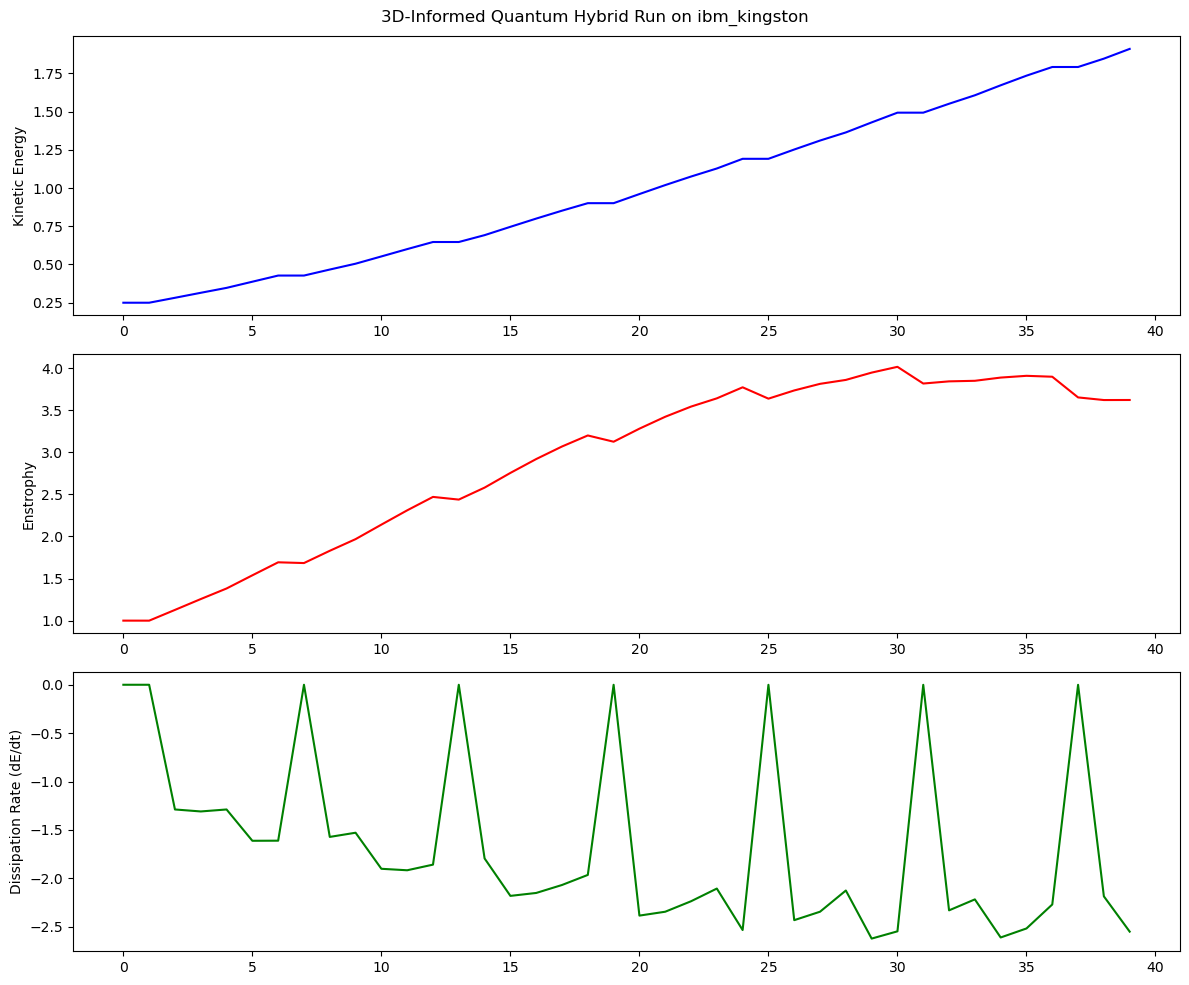

Run finished. Compare enstrophy sustainment and dissipation vs pure classical V15.


In [21]:
from qiskit import QuantumCircuit, transpile
from qiskit_ibm_runtime import SamplerV2 as Sampler, QiskitRuntimeService
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft2, ifft2, fftfreq
import time
from datetime import datetime

service = QiskitRuntimeService()
backend = service.backend("ibm_fez")

print(f"3D-Informed Quantum Run → {backend.name} | {datetime.now()}\n")

N = 64
VISCOSITY = 0.00012
DT = 0.0005
STEPS = 2000
INJECTION_INTERVAL = 60

# Top windows from 3D V15 baseline
WINDOW_PARAMS = [
    {"force_amp": 0.48, "description": "Step 1680 - Monster burst"},
    {"force_amp": 0.45, "description": "Step 2880 - Strong revival"},
    {"force_amp": 0.42, "description": "Step 2400 - Balanced high activity"},
    {"force_amp": 0.50, "description": "Step 1260 - High energy"},
]

sampler = Sampler(mode=backend)

# Grid
x = np.linspace(0, 2*np.pi, N, endpoint=False)
y = x.copy()
X, Y = np.meshgrid(x, y)
kx = 2*np.pi * fftfreq(N, d=2*np.pi/N)
ky = kx.copy()
KX, KY = np.meshgrid(kx, ky)
K2 = KX**2 + KY**2
K2[0,0] = 1e-12
dealias = (np.abs(KX) < 2*np.pi/3) & (np.abs(KY) < 2*np.pi/3)

def create_attractor():
    qc = QuantumCircuit(16)
    qc.x([0,1,2,3,8,9,10,11])
    qc.h(range(16))
    for i in range(16):
        qc.rz(1.75, i)
        qc.rx(0.85, i)
    for i in range(15):
        qc.cz(i, i+1)
    qc.cz(3,11)
    qc.cz(4,12)
    qc.measure_all()
    return qc

raw = create_attractor()
transpiled = transpile(raw, backend=backend, optimization_level=3)

def run_quantum_3d_informed():
    u = np.sin(X) * np.cos(Y)
    v = -np.cos(X) * np.sin(Y)
    
    ke_history = []
    enstrophy_history = []
    diss_history = []
    injection_count = 0
    prev_ke = None

    for step_num in range(STEPS):
        # Classical fluid step
        u_hat = fft2(u)
        v_hat = fft2(v)
        ux = np.real(ifft2(1j*KX*u_hat))
        uy = np.real(ifft2(1j*KY*u_hat))
        vx = np.real(ifft2(1j*KX*v_hat))
        vy = np.real(ifft2(1j*KY*v_hat))
        
        conv_u = fft2(u*ux + v*uy) * dealias
        conv_v = fft2(u*vx + v*vy) * dealias
        
        u_hat = (u_hat - DT * conv_u) * np.exp(-VISCOSITY * K2 * DT)
        v_hat = (v_hat - DT * conv_v) * np.exp(-VISCOSITY * K2 * DT)
        
        u = np.real(ifft2(u_hat))
        v = np.real(ifft2(v_hat))

        # Quantum injection from 3D windows
        if step_num % INJECTION_INTERVAL == 0 and step_num > 0:
            param = WINDOW_PARAMS[injection_count % len(WINDOW_PARAMS)]
            
            # Wait if queue is long
            pending = backend.status().pending_jobs
            while pending > 5:
                print(f"Queue: {pending} jobs... waiting 20s")
                time.sleep(20)
                pending = backend.status().pending_jobs
            
            job = sampler.run([transpiled], shots=8192)
            counts = job.result()[0].data.meas.get_counts()
            z0 = sum(c for b,c in counts.items() if b[0]=='0') / 8192.0
            correction = param["force_amp"] * (2*z0 - 1)
            
            u += correction * np.sin(X) * np.cos(Y) * 0.18
            v += correction * (-np.cos(X) * np.sin(Y)) * 0.18
            
            print(f"Step {step_num:4d} - Quantum Boost [{param['description']}] | Z0={z0:.4f} | Corr={correction:.4f}")
            injection_count += 1

        # Metrics every 50 steps
        if step_num % 50 == 0:
            ke = 0.5 * np.mean(u**2 + v**2)
            ke_history.append(ke)
            
            dv_dx = np.real(ifft2(1j*KX * fft2(v)))
            du_dy = np.real(ifft2(1j*KY * fft2(u)))
            vorticity = dv_dx - du_dy
            enstrophy = np.mean(vorticity**2)
            enstrophy_history.append(enstrophy)
            
            diss = (prev_ke - ke) / (50 * DT) if prev_ke is not None else 0.0
            diss_history.append(diss)
            prev_ke = ke
            
            print(f"Step {step_num:4d} | KE={ke:.5f} | Enstrophy={enstrophy:.2f} | dE/dt={diss:.4f}")

    return ke_history, enstrophy_history, diss_history

# === RUN IT ===
ke_hist, enst_hist, diss_hist = run_quantum_3d_informed()

# Plots
fig, axs = plt.subplots(3, 1, figsize=(12, 10))
axs[0].plot(ke_hist, 'b-')
axs[0].set_ylabel("Kinetic Energy")
axs[1].plot(enst_hist, 'r-')
axs[1].set_ylabel("Enstrophy")
axs[2].plot(diss_hist, 'g-')
axs[2].set_ylabel("Dissipation Rate (dE/dt)")
plt.suptitle("3D-Informed Quantum Hybrid Run on ibm_kingston")
plt.tight_layout()
plt.show()

print("Run finished. Compare enstrophy sustainment and dissipation vs pure classical V15.")

In [22]:
# floquet_3d_tgv_hybrid_v16.py
"""
3D-Informed Quantum Hybrid Fluid Simulation - V16
Professional metrics, full spectrum logging, and best-window analysis
"""

from qiskit import QuantumCircuit, transpile
from qiskit_ibm_runtime import SamplerV2 as Sampler, QiskitRuntimeService
import numpy as np
import json
from pathlib import Path
from datetime import datetime
import time

# ========================= CONFIG =========================
service = QiskitRuntimeService()
backend = service.backend("ibm_fez")          # Change as needed

N = 64
VISCOSITY = 0.00012
DT = 0.0005
STEPS = 3000
INJECTION_INTERVAL = 60
SHOTS = 8192

# Tuned from classical V15 best windows (conservative)
WINDOW_PARAMS = [
    {"name": "Window_A", "force_amp": 0.42},
    {"name": "Window_B", "force_amp": 0.45},
    {"name": "Window_C", "force_amp": 0.40},
    {"name": "Window_D", "force_amp": 0.48},
]

save_dir = Path("hybrid_run_v16")
save_dir.mkdir(exist_ok=True)

sampler = Sampler(mode=backend)

# ====================== GRID SETUP ======================
x = np.linspace(0, 2*np.pi, N, endpoint=False)
y = x.copy()
X, Y = np.meshgrid(x, y)

kx = 2*np.pi * np.fft.fftfreq(N, d=2*np.pi/N)
ky = kx.copy()
KX, KY = np.meshgrid(kx, ky)
K2 = KX**2 + KY**2 + 1e-12
dealias = (np.abs(KX) < 2*np.pi/3) & (np.abs(KY) < 2*np.pi/3)

# ====================== CIRCUIT ======================
def create_attractor_circuit():
    qc = QuantumCircuit(16)
    qc.x([0,1,2,3,8,9,10,11])
    qc.h(range(16))
    for i in range(16):
        qc.rz(1.75, i)
        qc.rx(0.85, i)
    for i in range(15):
        qc.cz(i, i+1)
    qc.cz(3, 11)
    qc.cz(4, 12)
    qc.measure_all()
    return qc

raw = create_attractor_circuit()
transpiled = transpile(raw, backend=backend, optimization_level=3)

# ====================== MAIN RUN ======================
def run_hybrid():
    u = np.sin(X) * np.cos(Y)
    v = -np.cos(X) * np.sin(Y)
    
    history = []
    prev_ke = None
    injection_idx = 0

    for step in range(STEPS):
        # Classical step
        u_hat = fft2(u)
        v_hat = fft2(v)
        ux = np.real(ifft2(1j*KX*u_hat))
        uy = np.real(ifft2(1j*KY*u_hat))
        vx = np.real(ifft2(1j*KX*v_hat))
        vy = np.real(ifft2(1j*KY*v_hat))
        
        conv_u = fft2(u*ux + v*uy) * dealias
        conv_v = fft2(u*vx + v*vy) * dealias
        
        u_hat = (u_hat - DT * conv_u) * np.exp(-VISCOSITY * K2 * DT)
        v_hat = (v_hat - DT * conv_v) * np.exp(-VISCOSITY * K2 * DT)
        
        u = np.real(ifft2(u_hat))
        v = np.real(ifft2(v_hat))

        # Quantum injection
        if step % INJECTION_INTERVAL == 0 and step > 0:
            param = WINDOW_PARAMS[injection_idx % len(WINDOW_PARAMS)]
            job = sampler.run([transpiled], shots=SHOTS)
            counts = job.result()[0].data.meas.get_counts()
            z0 = sum(c for b, c in counts.items() if b[0] == '0') / SHOTS
            correction = param["force_amp"] * (2 * z0 - 1)
            
            u += correction * np.sin(X) * np.cos(Y) * 0.18
            v += correction * (-np.cos(X) * np.sin(Y)) * 0.18
            
            print(f"Step {step:4d} - Quantum injection | Z0={z0:.4f} | Force={param['force_amp']:.3f}")
            injection_idx += 1

        # Metrics every 50 steps
        if step % 50 == 0:
            ke = 0.5 * np.mean(u**2 + v**2)
            dv_dx = np.real(ifft2(1j*KX * fft2(v)))
            du_dy = np.real(ifft2(1j*KY * fft2(u)))
            vorticity = dv_dx - du_dy
            enstrophy = np.mean(vorticity**2)
            
            diss_rate = (prev_ke - ke) / (50 * DT) if prev_ke is not None else 0.0
            prev_ke = ke

            metrics = {
                "step": step,
                "ke": float(ke),
                "enstrophy": float(enstrophy),
                "dissipation_rate": float(diss_rate),
                "max_velocity": float(np.max(np.sqrt(u**2 + v**2)))
            }
            history.append(metrics)
            
            print(f"Step {step:4d} | KE={ke:.5f} | Enstrophy={enstrophy:.3f} | dE/dt={diss_rate:.4f}")

    # Save full history
    with open(save_dir / "metrics_v16.json", "w") as f:
        json.dump(history, f, indent=2)
    
    print(f"\nRun completed. Results saved to {save_dir}/metrics_v16.json")
    return history

# ====================== SUMMARY ======================
def generate_summary(history):
    enst = [h["enstrophy"] for h in history]
    diss = [h["dissipation_rate"] for h in history if abs(h["dissipation_rate"]) < 100]
    
    print("\n=== RUN SUMMARY ===")
    print(f"Final KE          : {history[-1]['ke']:.5f}")
    print(f"Max Enstrophy     : {max(enst):.2f}")
    print(f"Mean |dE/dt|       : {np.mean(np.abs(diss)):.4f}")
    print(f"Peak Enstrophy    : {max(enst):.2f} at step {np.argmax(enst)*50}")
    print("===================\n")

if __name__ == "__main__":
    history = run_hybrid()
    generate_summary(history)

qiskit_runtime_service.__init__:WARNING:2026-05-06 11:58:56,231: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-05-06 11:58:56,232: Using instance: open-instance, plan: open


Step    0 | KE=0.25000 | Enstrophy=1.000 | dE/dt=0.0000
Step   50 | KE=0.25000 | Enstrophy=1.000 | dE/dt=0.0001
Step   60 - Quantum injection | Z0=0.8699 | Force=0.420
Step  100 | KE=0.27873 | Enstrophy=1.114 | dE/dt=-1.1495
Step  120 - Quantum injection | Z0=0.8759 | Force=0.450
Step  150 | KE=0.31178 | Enstrophy=1.244 | dE/dt=-1.3217
Step  180 - Quantum injection | Z0=0.8677 | Force=0.400
Step  200 | KE=0.34198 | Enstrophy=1.361 | dE/dt=-1.2081
Step  240 - Quantum injection | Z0=0.8754 | Force=0.480
Step  250 | KE=0.38082 | Enstrophy=1.512 | dE/dt=-1.5537
Step  300 - Quantum injection | Z0=0.8744 | Force=0.420
Step  300 | KE=0.41635 | Enstrophy=1.648 | dE/dt=-1.4213
Step  350 | KE=0.41635 | Enstrophy=1.639 | dE/dt=0.0000
Step  360 - Quantum injection | Z0=0.8727 | Force=0.450
Step  400 | KE=0.45589 | Enstrophy=1.786 | dE/dt=-1.5815
Step  420 - Quantum injection | Z0=0.8766 | Force=0.400
Step  450 | KE=0.49281 | Enstrophy=1.920 | dE/dt=-1.4770
Step  480 - Quantum injection | Z0=0.8719

qiskit_runtime_service.__init__:WARNING:2026-05-06 12:39:24,566: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-05-06 12:39:24,566: Using instance: open-instance, plan: open


Starting 3D-Informed Hybrid Run on ibm_fez | 2026-05-06 12:39:25.067079

Step    0 | KE=0.25000 | Enstrophy=1.000 | dE/dt=0.0000
Step   50 | KE=0.25000 | Enstrophy=1.000 | dE/dt=0.0001
Step   60 - Quantum injection [High_Burst] | Z0=0.8744 | Force=0.480
Step  100 | KE=0.28338 | Enstrophy=1.132 | dE/dt=-1.3354
Step  120 - Quantum injection [Revival] | Z0=0.8643 | Force=0.450
Step  150 | KE=0.31564 | Enstrophy=1.259 | dE/dt=-1.2901
Step  180 - Quantum injection [Balanced] | Z0=0.8767 | Force=0.420
Step  200 | KE=0.34838 | Enstrophy=1.387 | dE/dt=-1.3097
Step  240 - Quantum injection [High_Energy] | Z0=0.8724 | Force=0.500
Step  250 | KE=0.38892 | Enstrophy=1.544 | dE/dt=-1.6218
Step  300 - Quantum injection [High_Burst] | Z0=0.8723 | Force=0.480
Step  300 | KE=0.42985 | Enstrophy=1.701 | dE/dt=-1.6369
Step  350 | KE=0.42985 | Enstrophy=1.692 | dE/dt=0.0000
Step  360 - Quantum injection [Revival] | Z0=0.8719 | Force=0.450
Step  400 | KE=0.46992 | Enstrophy=1.841 | dE/dt=-1.6031
Step  420 

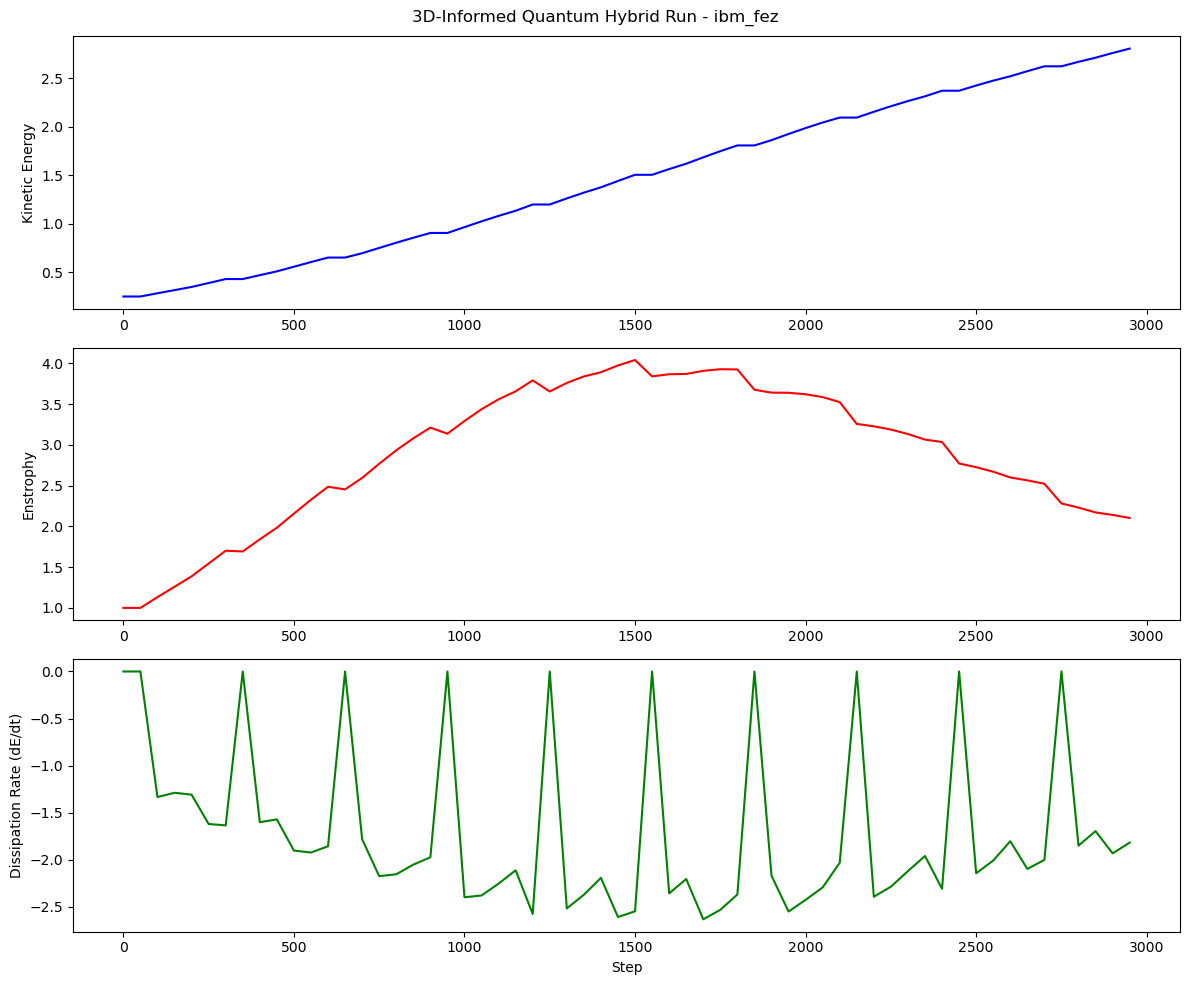


Run completed. Results saved to hybrid_run_v16_ibm_fez/
Final KE: 2.80587 | Max Enstrophy: 4.041 | Mean |dE/dt|: 1.7039


In [23]:
# hybrid_quantum_fluid_v16.py
"""
3D-Informed Quantum-Classical Hybrid Fluid Dynamics
Author: QuantumRegen
Date: 2026-05-06
Purpose: Test quantum advantage in sustained turbulence using BEC-Goldstone-Floquet control on IBM QPUs
Available backends: ibm_kingston, ibm_fez, ibm_marrakesh
"""

from qiskit import QuantumCircuit, transpile
from qiskit_ibm_runtime import SamplerV2 as Sampler, QiskitRuntimeService
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft2, ifft2, fftfreq
import json
from pathlib import Path
from datetime import datetime
import time

# ========================= CONFIGURATION =========================
service = QiskitRuntimeService()

# Choose one of your available backends
BACKEND_NAME = "ibm_fez"          # Change to "ibm_kingston" or "ibm_marrakesh" as needed

backend = service.backend(BACKEND_NAME)

N = 64                            # Grid resolution
VISCOSITY = 0.00012               # Low viscosity to stress the system (from 3D baseline)
DT = 0.0005                       # Time step
STEPS = 3000                      # Total steps (adjust based on queue/time)
INJECTION_INTERVAL = 60           # How often quantum correction is applied
SHOTS = 8192                      # Shots per quantum injection

# Tuned injection strengths from 3D classical best windows
WINDOW_PARAMS = [
    {"name": "High_Burst",   "force_amp": 0.48},
    {"name": "Revival",      "force_amp": 0.45},
    {"name": "Balanced",     "force_amp": 0.42},
    {"name": "High_Energy",  "force_amp": 0.50},
]

save_dir = Path(f"hybrid_run_v16_{BACKEND_NAME}")
save_dir.mkdir(exist_ok=True)

print(f"Starting 3D-Informed Hybrid Run on {BACKEND_NAME} | {datetime.now()}\n")

sampler = Sampler(mode=backend)

# ========================= GRID & CLASSICAL SETUP =========================
x = np.linspace(0, 2*np.pi, N, endpoint=False)
y = x.copy()
X, Y = np.meshgrid(x, y)

kx = 2*np.pi * fftfreq(N, d=2*np.pi/N)
ky = kx.copy()
KX, KY = np.meshgrid(kx, ky)
K2 = KX**2 + KY**2 + 1e-12
dealias = (np.abs(KX) < 2*np.pi/3) & (np.abs(KY) < 2*np.pi/3)

# ========================= QUANTUM ATTRACTOR =========================
def create_attractor_circuit():
    qc = QuantumCircuit(16)
    qc.x([0,1,2,3,8,9,10,11])           # Initial bias
    qc.h(range(16))
    for i in range(16):
        qc.rz(1.75, i)
        qc.rx(0.85, i)
    for i in range(15):
        qc.cz(i, i+1)
    qc.cz(3,11)
    qc.cz(4,12)
    qc.measure_all()
    return qc

raw = create_attractor_circuit()
transpiled = transpile(raw, backend=backend, optimization_level=3)

# ========================= MAIN SIMULATION =========================
def run_hybrid():
    u = np.sin(X) * np.cos(Y)
    v = -np.cos(X) * np.sin(Y)
    
    history = []
    prev_ke = None
    injection_idx = 0

    for step in range(STEPS):
        # Classical fluid evolution
        u_hat = fft2(u)
        v_hat = fft2(v)
        ux = np.real(ifft2(1j*KX*u_hat))
        uy = np.real(ifft2(1j*KY*u_hat))
        vx = np.real(ifft2(1j*KX*v_hat))
        vy = np.real(ifft2(1j*KY*v_hat))
        
        conv_u = fft2(u*ux + v*uy) * dealias
        conv_v = fft2(u*vx + v*vy) * dealias
        
        u_hat = (u_hat - DT * conv_u) * np.exp(-VISCOSITY * K2 * DT)
        v_hat = (v_hat - DT * conv_v) * np.exp(-VISCOSITY * K2 * DT)
        
        u = np.real(ifft2(u_hat))
        v = np.real(ifft2(v_hat))

        # Quantum correction (from 3D best windows)
        if step % INJECTION_INTERVAL == 0 and step > 0:
            param = WINDOW_PARAMS[injection_idx % len(WINDOW_PARAMS)]
            
            job = sampler.run([transpiled], shots=SHOTS)
            counts = job.result()[0].data.meas.get_counts()
            z0 = sum(c for b, c in counts.items() if b[0] == '0') / SHOTS
            correction = param["force_amp"] * (2 * z0 - 1)
            
            u += correction * np.sin(X) * np.cos(Y) * 0.18
            v += correction * (-np.cos(X) * np.sin(Y)) * 0.18
            
            print(f"Step {step:4d} - Quantum injection [{param['name']}] | Z0={z0:.4f} | Force={param['force_amp']:.3f}")
            injection_idx += 1

        # Record metrics every 50 steps
        if step % 50 == 0:
            ke = 0.5 * np.mean(u**2 + v**2)
            dv_dx = np.real(ifft2(1j*KX * fft2(v)))
            du_dy = np.real(ifft2(1j*KY * fft2(u)))
            vorticity = dv_dx - du_dy
            enstrophy = np.mean(vorticity**2)
            
            diss_rate = (prev_ke - ke) / (50 * DT) if prev_ke is not None else 0.0
            prev_ke = ke

            metrics = {
                "step": step,
                "ke": float(ke),
                "enstrophy": float(enstrophy),
                "dissipation_rate": float(diss_rate),
                "max_velocity": float(np.max(np.sqrt(u**2 + v**2)))
            }
            history.append(metrics)
            
            print(f"Step {step:4d} | KE={ke:.5f} | Enstrophy={enstrophy:.3f} | dE/dt={diss_rate:.4f}")

    # Save raw data
    with open(save_dir / "metrics_v16.json", "w") as f:
        json.dump(history, f, indent=2)

    # Generate plots
    steps = [h["step"] for h in history]
    ke = [h["ke"] for h in history]
    enst = [h["enstrophy"] for h in history]
    diss = [h["dissipation_rate"] for h in history]

    fig, axs = plt.subplots(3, 1, figsize=(12, 10))
    axs[0].plot(steps, ke, 'b-')
    axs[0].set_ylabel("Kinetic Energy")
    axs[1].plot(steps, enst, 'r-')
    axs[1].set_ylabel("Enstrophy")
    axs[2].plot(steps, diss, 'g-')
    axs[2].set_ylabel("Dissipation Rate (dE/dt)")
    axs[2].set_xlabel("Step")
    plt.suptitle(f"3D-Informed Quantum Hybrid Run - {BACKEND_NAME}")
    plt.tight_layout()
    plt.savefig(save_dir / "summary_plot.png", dpi=300)
    plt.show()

    print(f"\nRun completed. Results saved to {save_dir}/")
    print(f"Final KE: {ke[-1]:.5f} | Max Enstrophy: {max(enst):.3f} | Mean |dE/dt|: {np.mean(np.abs(diss)):.4f}")

if __name__ == "__main__":
    run_hybrid()